## ДЗ №4 «Портфель - средство снижения риска»

**Студент**: Сизиков Константин.

**Цель**:
 - Студенты учатся формировать портфельную стратегию для снижения риска и пвышения качества модели.
 - Результат - сформирована модель на базе портфельной стратегии.


**Описание/Пошаговая инструкция выполнения домашнего задания**:
 - Создать модель (торговую стратегию) на основе классического портфеля.
 - Протестировать различные уровни риска как гиперпараметра модели для достижения вашего конкретного уровня доходности/риска.
 - Провести тестирование разработанной стратегии на валидационном датасете.
 - Сформировать дашборд, показывающий эффективность различных портфелей по критерию риск/доходность.
 - Подробнее с описанием вы можете ознакомиться в файле, приложенном к материалам занятия.




## Модель

Стратегия строится в два шага.

1. **Шаг 1.** Смотрим на историю цен акций и оцениваем, какая у них была средняя доходность и насколько сильно они колеблются относительно друг друга (это и есть риск). На основе этого собираем портфель — либо с максимальной доходностью на единицу риска, либо подогнанный под заданный уровень риска.
2. **Шаг 2.** Полученный рисковый портфель смешиваем с безрисковым активом (условно — депозит/денежный рынок), чтобы итоговая волатильность всего портфеля попала в нужный целевой уровень: если рисковый портфель более волатильный, чем нужно, часть денег держим в кэше; если менее волатильный — почти всё вкладываем в рисковые активы.

Главный настраиваемый параметр — целевой уровень риска (волатильности). Дополнительно перебираем способ оценки ожидаемой доходности (это самое слабое место в модели Марковица) и силу сглаживания весов, чтобы портфель не получался слишком концентрированным в нескольких бумагах.

**Проверка модели без утечек данных.** Данные делим на три части: 60% — обучение, 15% — подбор гиперпараметров, 25% — финальная проверка, которую ни разу не видели при настройке. Внутри каждого периода веса портфеля на каждую дату ребалансировки пересчитываются только по данным, известным на тот момент, без заглядывания вперёд.

---

**Требования к портфелю до экспериментов**:

| Параметр | Значение |
|---|---|
| Целевая годовая волатильность | **12%** (допустимый коридор 8…16%) |
| Максимальная просадка | не глубже **15%** |
| Целевая доходность | не ниже безрисковой ставки (money market, ключевая ставка ЦБ) |
| Позиции | только long, без плеча, доля одной бумаги ≤ 15% |
| Ребалансировка | раз в месяц (21 торговый день), издержки 10 б.п. от оборота |

**Данные:** `stocks_day.csv` — дневные цены закрытия ~91 акции Мосбиржи
за период 2023-12-11 … 2024-12-03 (251 торговый день).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import itertools
from dataclasses import dataclass, field

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import seaborn as sns

from pypfopt import EfficientFrontier, risk_models, expected_returns, objective_functions
from pypfopt import DiscreteAllocation, get_latest_prices

# --------------------------------------------------------------------------------------
# Глобальная конфигурация
# --------------------------------------------------------------------------------------
DATA_PATH = "stocks_day.csv"

TRADING_DAYS = 252            # торговых дней в году
RISK_FREE_RATE = 0.18         # ~средняя ключевая ставка ЦБ РФ за период (16% -> 21%)
RF_DAILY = (1 + RISK_FREE_RATE) ** (1 / TRADING_DAYS) - 1

MAX_NAN_SHARE = 0.05          # выбрасываем бумагу, если пропусков больше 5%
SPIKE_THRESHOLD = 0.40        # |дневная доходность| для детекции битого тика
MAX_ASSET_VOL = 1.20          # выбрасываем бумаги с годовой волатильностью > 120%

TRAIN_SHARE, TUNE_SHARE = 0.60, 0.15   # остальное (25%) -- VALID

REBALANCE_DAYS = 21           # ребалансировка раз в месяц
COST_BPS = 10                 # издержки, б.п. от оборота
WEIGHT_CAP = 0.15             # максимальная доля одной бумаги
LOOKBACK = None               # None -> расширяющееся окно оценки mu/Sigma

# Мандат
TARGET_VOL_MANDATE = 0.12
VOL_TOLERANCE = 0.04
MAX_DD_MANDATE = -0.15

PORTFOLIO_VALUE = 1_000_000   # рублей, для дискретной аллокации

RANDOM_STATE = 42

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rcParams.update({
    "figure.figsize": (13, 5.5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "font.size": 10,
    "legend.frameon": True,
})
PCT = FuncFormatter(lambda x, _: f"{x:.0%}")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
print(f"Безрисковая ставка: {RISK_FREE_RATE:.1%} годовых ({RF_DAILY*100:.4f}% в день)")

## 1. Загрузка и очистка данных

Очищвем данные:

1. удаляем бумаги, где пропущено более 5 % наблюдений (низкая ликвидность / позднее размещение);
2. заполняем оставшиеся пропуски последним известным значением (`ffill` + `bfill`);
3. сглаживаем одиночные скачки
   (например, `tgka`: 0.1005 → 0.9988 → 0.9966: явная ошибка масштаба, а не движение цены);
4. удаляем бумаги, у которых после ремонта осталась аномальная волатильность (> 120 % годовых)
   или одиночные движения более 40 % за день — такие ряды разрушают оценку ковариаций.

In [2]:
prices_raw = pd.read_csv(DATA_PATH, parse_dates=["time"]).set_index("time").sort_index()
prices_raw.index = prices_raw.index.tz_localize(None)
prices_raw.index.name = "date"

print(f"Загружено: {prices_raw.shape[0]} дней x {prices_raw.shape[1]} бумаг")
print(f"Период: {prices_raw.index.min():%Y-%m-%d} ... {prices_raw.index.max():%Y-%m-%d}")
prices_raw.iloc[:5, :8]

Загружено: 251 дней x 91 бумаг
Период: 2023-12-11 ... 2024-12-03


,krot,vkco,svav,vsmo,nomp,grnt,nsvz,gltr
date,,,,,,,,
2023-12-11,2322.0,575.0,712.0,30860.0,499.99,0.2484,479.0,594.0
2023-12-12,2310.0,546.8,690.0,30120.0,473.99,0.2400,465.0,587.9
2023-12-13,2298.0,563.0,696.0,29200.0,499.99,0.2200,470.0,583.5
2023-12-14,2232.0,564.0,697.5,28980.0,497.00,0.2088,464.0,581.0
2023-12-15,2309.0,573.4,713.0,28880.0,464.00,0.1982,460.0,593.8


Доля пропусков (топ-20):
data     81.7
sftl     69.7
prmd     59.0
vseh     57.0
hhru     32.7
leas     29.9
klvz     20.3
grnt     18.3
deli     15.9
gltr     12.7
udmn      8.0
t         7.6
mgkl      5.2
obne      2.0
svcb      1.6
gmkn      1.6
vtbr      1.6
trnfp     1.6


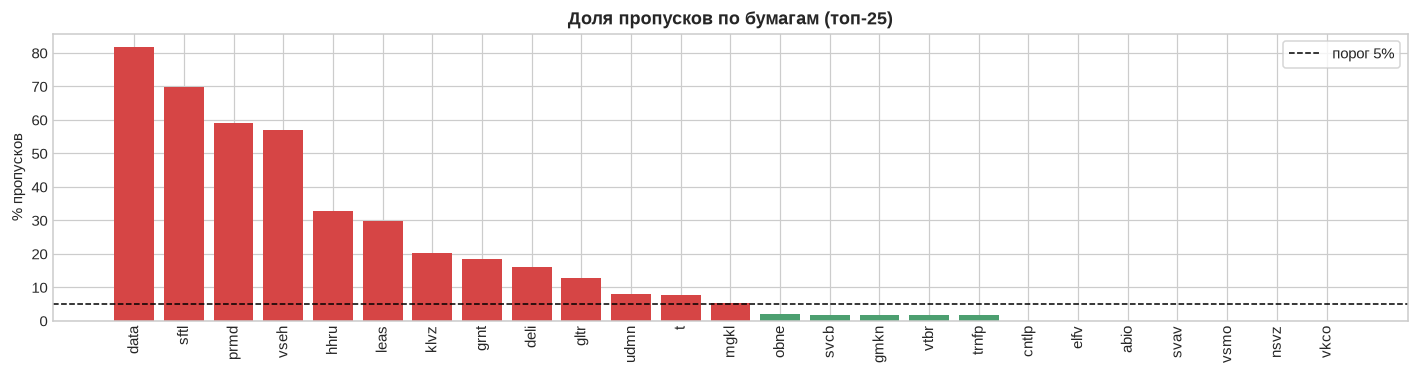

In [3]:
nan_share = prices_raw.isna().mean().sort_values(ascending=False)
print("Доля пропусков (топ-20):")
print((nan_share[nan_share > 0] * 100).round(1).head(20).to_string())

fig, ax = plt.subplots(figsize=(13, 3.5))
top = nan_share.head(25)
ax.bar(top.index, top.values * 100, color=np.where(top.values > MAX_NAN_SHARE, "#d64545", "#4c9f70"))
ax.axhline(MAX_NAN_SHARE * 100, ls="--", c="k", lw=1, label=f"порог {MAX_NAN_SHARE:.0%}")
ax.set_title("Доля пропусков по бумагам (топ-25)")
ax.set_ylabel("% пропусков")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout(); plt.show()

In [4]:
def clean_prices(prices: pd.DataFrame,
                 max_nan_share: float = MAX_NAN_SHARE,
                 spike_threshold: float = SPIKE_THRESHOLD,
                 max_vol: float = MAX_ASSET_VOL,
                 verbose: bool = True) -> pd.DataFrame:
    """Очистка панели цен: пропуски, битые тики, аномальные бумаги."""
    report = {}

    # 1. пропуски
    share = prices.isna().mean()
    dropped_nan = sorted(share[share > max_nan_share].index)
    px = prices.loc[:, share <= max_nan_share].ffill().bfill().astype(float)
    report["dropped_by_nan"] = dropped_nan

    # 2. ремонт битых тиков: скачок и немедленный возврат (V-образная свеча)
    ret = px.pct_change()
    nxt = ret.shift(-1)
    spikes = (ret.abs() > spike_threshold) & (nxt.abs() > spike_threshold) & (ret * nxt < -0.15)
    report["spikes_repaired"] = {c: int(n) for c, n in spikes.sum().items() if n}
    px = px.mask(spikes).interpolate(limit_direction="both")

    # 3. аномальные бумаги
    ret = px.pct_change().dropna(how="all")
    ann_vol = ret.std() * np.sqrt(TRADING_DAYS)
    bad = ann_vol[(ann_vol > max_vol) | (ret.abs().max() > spike_threshold)]
    report["dropped_by_vol"] = sorted(bad.index)
    px = px.drop(columns=bad.index)

    if verbose:
        print(f"[1] по пропускам (>{max_nan_share:.0%}) удалено {len(dropped_nan)}: {dropped_nan}")
        print(f"[2] отремонтировано битых тиков: {sum(report['spikes_repaired'].values())} "
              f"в {len(report['spikes_repaired'])} бумагах -> {report['spikes_repaired']}")
        print(f"[3] по аномальной волатильности удалено {len(bad)}: {report['dropped_by_vol']}")
        print(f"\nИтого к работе: {px.shape[0]} дней x {px.shape[1]} бумаг")

    px.attrs["clean_report"] = report
    return px


prices = clean_prices(prices_raw)
returns = prices.pct_change().fillna(0.0)

[1] по пропускам (>5%) удалено 13: ['data', 'deli', 'gltr', 'grnt', 'hhru', 'klvz', 'leas', 'mgkl', 'prmd', 'sftl', 't', 'udmn', 'vseh']
[2] отремонтировано битых тиков: 17 в 5 бумагах -> {'tgka': 3, 'mrks': 1, 'tgkb': 3, 'ttlk': 7, 'mrkz': 3}
[3] по аномальной волатильности удалено 10: ['dvec', 'mrkz', 'obne', 'orup', 'rolo', 'slav', 'tgka', 'tgkb', 'ttlk', 'unac']

Итого к работе: 251 дней x 68 бумаг


In [5]:
ret_obs = returns.iloc[1:]      # первый день -- искусственный нуль от fillna, исключаем
asset_stats = pd.DataFrame({
    "ann_return": (1 + ret_obs).prod() ** (TRADING_DAYS / len(ret_obs)) - 1,
    "ann_vol": ret_obs.std() * np.sqrt(TRADING_DAYS),
    "max_dd": ((prices / prices.cummax()) - 1).min(),
})
asset_stats["sharpe"] = (asset_stats["ann_return"] - RISK_FREE_RATE) / asset_stats["ann_vol"]
print("Статистика по бумагам за весь период (топ-5 и худшие-5 по доходности):")
print(pd.concat([asset_stats.sort_values("ann_return", ascending=False).head(5),
                 asset_stats.sort_values("ann_return").head(5)]).round(3).to_string())
print(f"\nМедианная годовая доходность бумаги: {asset_stats['ann_return'].median():.1%}, "
      f"медианная волатильность: {asset_stats['ann_vol'].median():.1%}")
print(f"Бумаг с доходностью выше безрисковой ставки: "
      f"{(asset_stats['ann_return'] > RISK_FREE_RATE).sum()} из {len(asset_stats)}")

Статистика по бумагам за весь период (топ-5 и худшие-5 по доходности):
      ann_return  ann_vol  max_dd  sharpe
sfin       1.450    0.720  -0.451   1.765
lent       0.569    0.407  -0.231   0.955
rbcm       0.479    0.719  -0.564   0.416
lsrg       0.130    0.384  -0.468  -0.130
mrkv       0.127    0.358  -0.260  -0.147
mtlr      -0.703    0.380  -0.756  -2.322
sgzh      -0.690    1.063  -0.764  -0.819
qiwi      -0.606    0.856  -0.768  -0.918
eutr      -0.605    0.745  -0.801  -1.054
nomp      -0.557    0.608  -0.607  -1.211

Медианная годовая доходность бумаги: -24.9%, медианная волатильность: 40.0%
Бумаг с доходностью выше безрисковой ставки: 3 из 68


## 2. Разбиение на TRAIN / TUNE / VALID

Разбиение строго по времени (никакого перемешивания — это временные ряды):

* **TRAIN** — первые 60 % истории: начальная оценка $\mu, \Sigma$ и эффективной границы;
* **TUNE** — следующие 15 %: honest out-of-sample для **выбора гиперпараметров**;
* **VALID** — последние 25 %: финальная проверка выбранной конфигурации.

In [6]:
n_obs = len(prices)
i_train_end = int(n_obs * TRAIN_SHARE)
i_tune_end = int(n_obs * (TRAIN_SHARE + TUNE_SHARE))

SPLITS = {
    "TRAIN": (0, i_train_end),
    "TUNE": (i_train_end, i_tune_end),
    "VALID": (i_tune_end, n_obs),
}
train_prices = prices.iloc[:i_train_end]

split_info = pd.DataFrame([
    {"выборка": k, "дней": b - a,
     "начало": prices.index[a].date(), "конец": prices.index[b - 1].date()}
    for k, (a, b) in SPLITS.items()
])
print(split_info.to_string(index=False))

выборка  дней     начало      конец
  TRAIN   150 2023-12-11 2024-07-15
   TUNE    38 2024-07-16 2024-09-05
  VALID    63 2024-09-06 2024-12-03


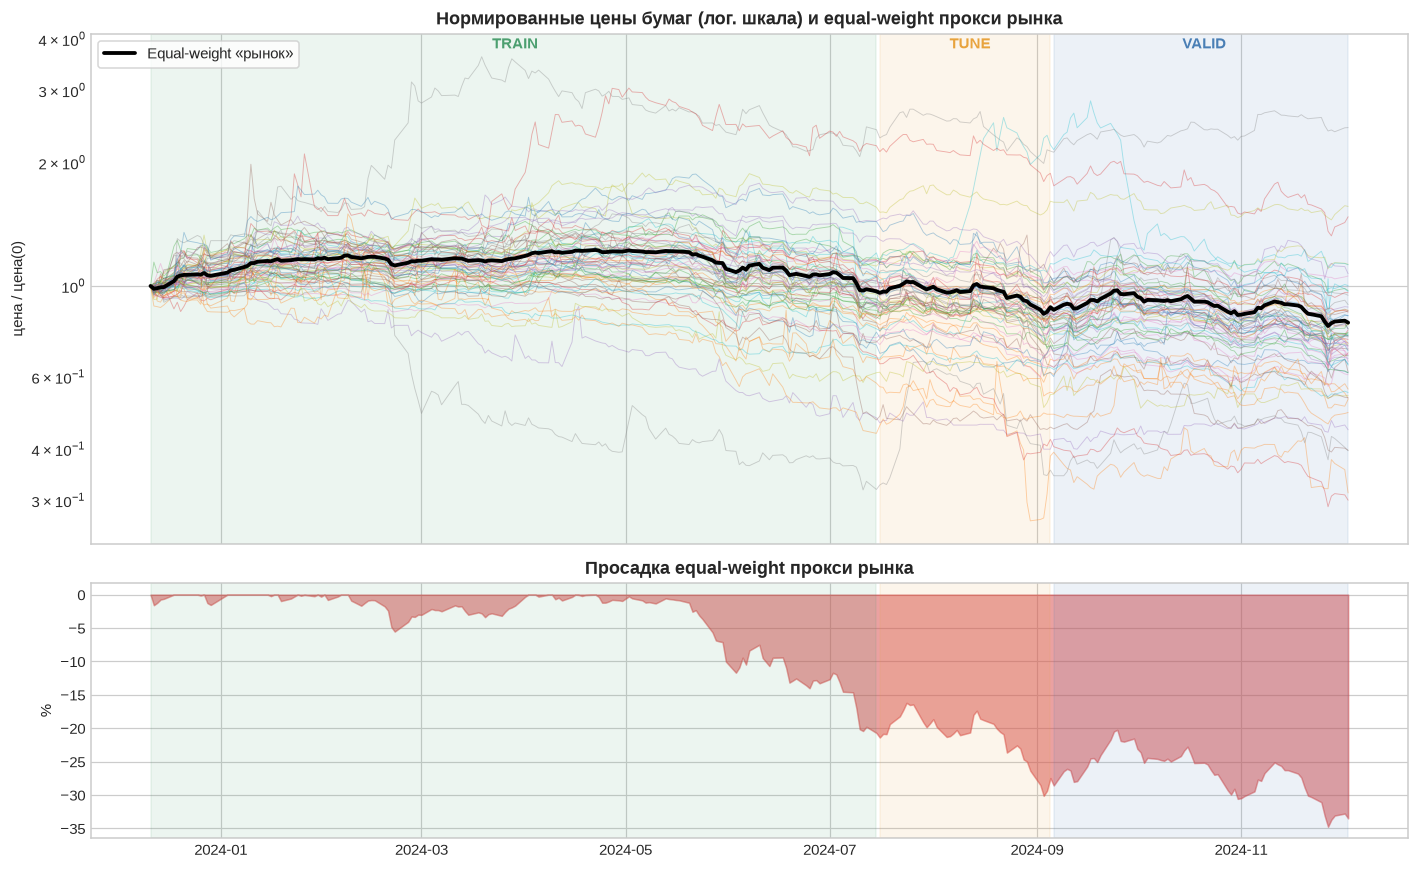

Доходность equal-weight прокси рынка по периодам:
  TRAIN   -2.96% за 150 дней  (годовых:  -4.92%)
  TUNE    -8.53% за 38 дней  (годовых: -44.62%)
  VALID   -8.31% за 63 дней  (годовых: -29.31%)


In [7]:
# equal-weight прокси «рынка» с ежедневной ребалансировкой -- то же определение,
# что и у бенчмарка "Equal-weight" в бэктесте ниже
market_ret = returns.mean(axis=1)
market = (1 + market_ret).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
norm = prices / prices.iloc[0]
axes[0].plot(norm.index, norm.values, lw=0.6, alpha=0.35)
axes[0].plot(market.index, market.values, lw=2.5, color="k", label="Equal-weight «рынок»")
axes[0].set_yscale("log")
axes[0].set_title("Нормированные цены бумаг (лог. шкала) и equal-weight прокси рынка")
axes[0].set_ylabel("цена / цена(0)")
axes[0].legend(loc="upper left")

axes[1].fill_between(market.index, (market / market.cummax() - 1) * 100, 0,
                     color="#d64545", alpha=0.5)
axes[1].set_title("Просадка equal-weight прокси рынка")
axes[1].set_ylabel("%")

colors = {"TRAIN": "#4c9f70", "TUNE": "#e8a33d", "VALID": "#4a7fb5"}
for ax in axes:
    for name, (a, b) in SPLITS.items():
        ax.axvspan(prices.index[a], prices.index[b - 1], color=colors[name], alpha=0.10)
        if ax is axes[0]:
            ax.text(prices.index[(a + b) // 2], ax.get_ylim()[1] * 0.92, name,
                    ha="center", fontweight="bold", color=colors[name])
plt.tight_layout(); plt.show()

print("Доходность equal-weight прокси рынка по периодам:")
for name, (a, b) in SPLITS.items():
    seg = market_ret.iloc[a:b]
    tot = (1 + seg).prod() - 1
    print(f"  {name:<6} {tot:+7.2%} за {b-a} дней  (годовых: {(1+tot)**(TRADING_DAYS/(b-a))-1:+7.2%})")

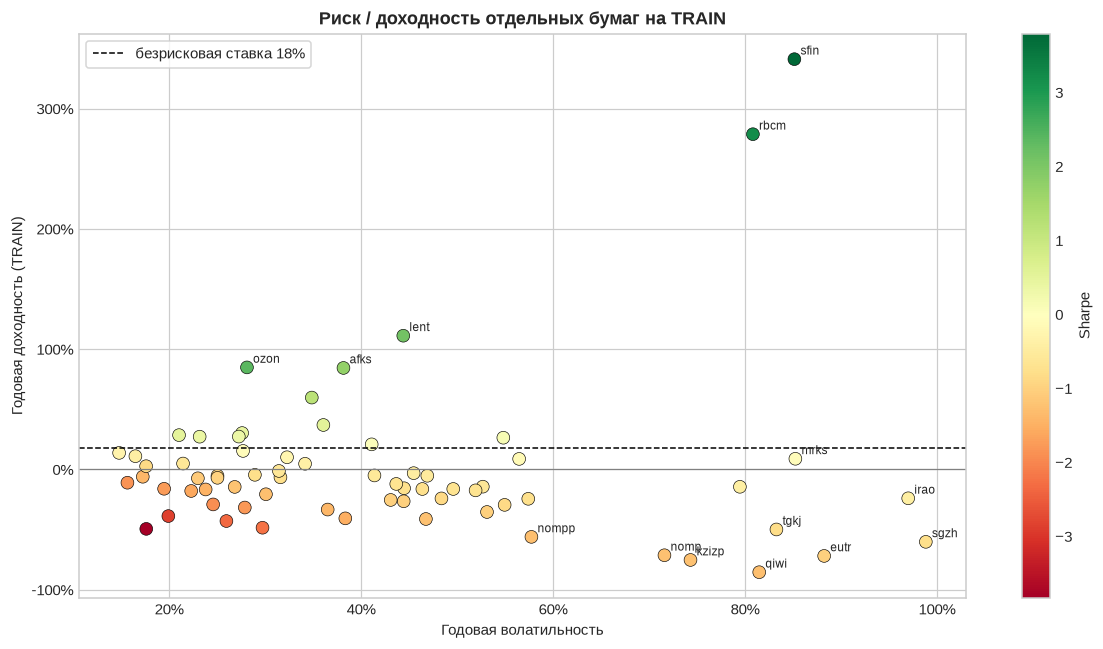

In [8]:
train_stats = pd.DataFrame({
    "mu": expected_returns.mean_historical_return(train_prices),
    "vol": train_prices.pct_change().std() * np.sqrt(TRADING_DAYS),
})
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(train_stats["vol"], train_stats["mu"],
                c=(train_stats["mu"] - RISK_FREE_RATE) / train_stats["vol"],
                cmap="RdYlGn", s=70, edgecolor="k", lw=0.4)
for t in train_stats.index:
    if train_stats.loc[t, "mu"] > 0.8 or train_stats.loc[t, "mu"] < -0.55 or train_stats.loc[t, "vol"] > 0.8:
        ax.annotate(t, (train_stats.loc[t, "vol"], train_stats.loc[t, "mu"]),
                    fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.axhline(RISK_FREE_RATE, ls="--", c="k", lw=1, label=f"безрисковая ставка {RISK_FREE_RATE:.0%}")
ax.axhline(0, c="grey", lw=0.8)
ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Годовая волатильность"); ax.set_ylabel("Годовая доходность (TRAIN)")
ax.set_title("Риск / доходность отдельных бумаг на TRAIN")
plt.colorbar(sc, ax=ax, label="Sharpe")
ax.legend(); plt.tight_layout(); plt.show()

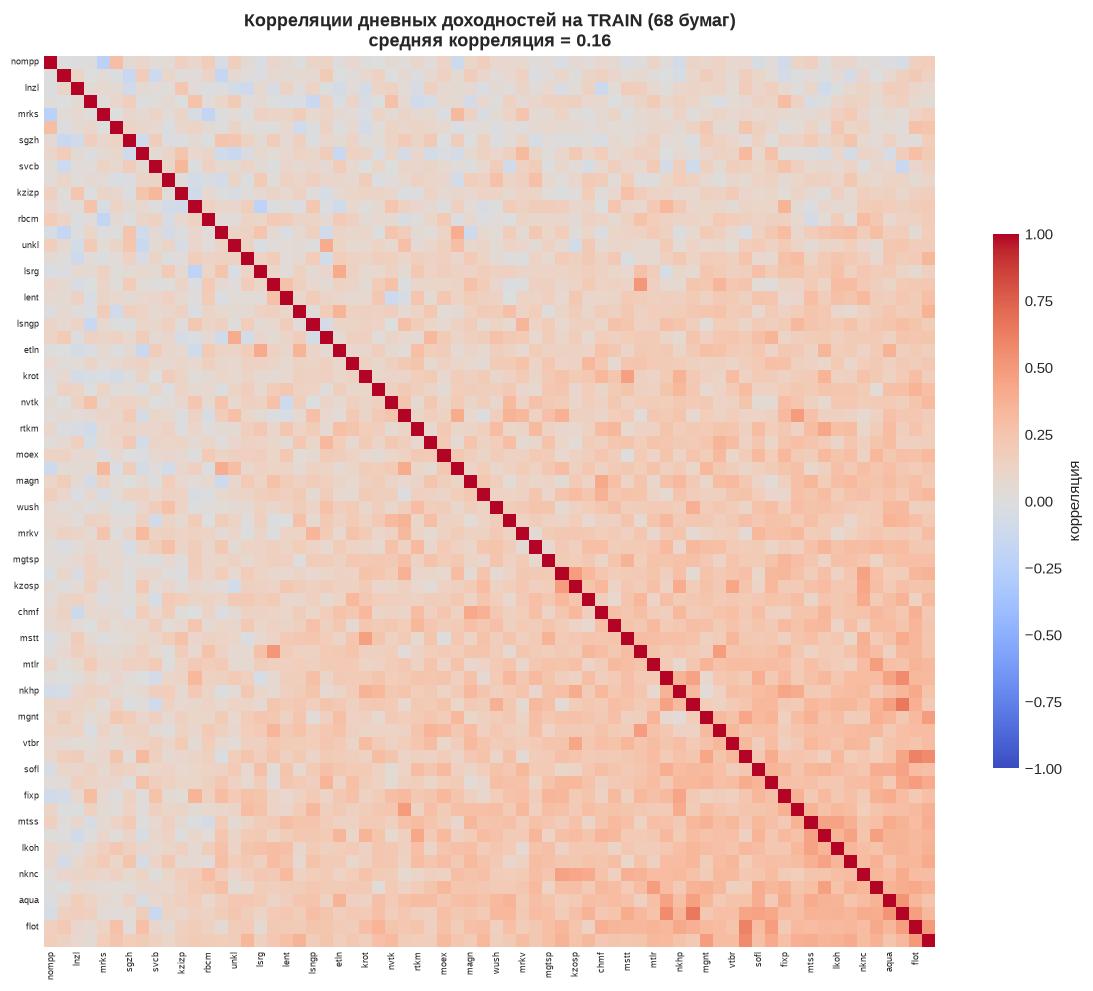

In [9]:
corr = train_prices.pct_change().dropna().corr()
order = corr.mean().sort_values().index
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr.loc[order, order], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.6, "label": "корреляция"}, ax=ax)
ax.set_title(f"Корреляции дневных доходностей на TRAIN ({len(corr)} бумаг)\n"
             f"средняя корреляция = {corr.values[np.triu_indices_from(corr, 1)].mean():.2f}")
ax.tick_params(labelsize=6)
plt.tight_layout(); plt.show()

## 3. Модель: классический портфель Марковица + безрисковый актив

### 3.1 Оценка входных параметров

Слабое место модели Марковица — оценка ожидаемой доходности: историческое среднее очень шумное,
и оптимизатор начинает «влюбляться» в бумаги, которые просто случайно выросли за прошлый период.
Поэтому способ оценки ожидаемой доходности делаем настраиваемым параметром:

| `mu_method` | Описание |
|---|---|
| `hist` | среднегеометрическая историческая доходность |
| `ema` | экспоненциально взвешенное среднее (окно 60 дней) — быстрее реагирует на смену тренда |
| `shrunk` | доходность каждой бумаги немного «подтягивается» к среднему по всем бумагам, чтобы сгладить случайные выбросы |
| `capm` | доходности оцениваются через CAPM относительно equal-weight «рынка» |

Для оценки того, как бумаги колеблются совместно (ковариации), используем метод Ledoit–Wolf
вместо обычной выборочной ковариации: бумаг у нас 68, а наблюдений — около 150, поэтому обычная
оценка получается неустойчивой, и на её шуме оптимизатор строит нереалистично большие ставки.
Метод Ledoit–Wolf сглаживает эту оценку и делает её надёжнее.

Дополнительно ограничиваем модель: штраф за слишком большие веса (`gamma`) и жёсткий лимит — не
более 15% портфеля в одной бумаге.

In [10]:
def estimate_mu(prices: pd.DataFrame, method: str = "shrunk") -> pd.Series:
    """Оценка вектора ожидаемых годовых доходностей."""
    if method == "hist":
        return expected_returns.mean_historical_return(prices, frequency=TRADING_DAYS)
    if method == "ema":
        return expected_returns.ema_historical_return(prices, frequency=TRADING_DAYS, span=60)
    if method == "shrunk":
        mu = expected_returns.mean_historical_return(prices, frequency=TRADING_DAYS)
        return 0.3 * mu + 0.7 * mu.mean()
    if method == "capm":
        return expected_returns.capm_return(prices, risk_free_rate=RISK_FREE_RATE,
                                            frequency=TRADING_DAYS)
    raise ValueError(f"unknown mu_method: {method}")


def estimate_sigma(prices: pd.DataFrame, method: str = "ledoit_wolf") -> pd.DataFrame:
    """Оценка ковариационной матрицы годовых доходностей."""
    if method == "ledoit_wolf":
        return risk_models.CovarianceShrinkage(prices, frequency=TRADING_DAYS).ledoit_wolf()
    if method == "sample":
        return risk_models.sample_cov(prices, frequency=TRADING_DAYS)
    if method == "exp":
        return risk_models.exp_cov(prices, frequency=TRADING_DAYS, span=90)
    raise ValueError(f"unknown cov_method: {method}")


# демонстрация: насколько разные оценки mu расходятся между собой
mu_variants = pd.DataFrame({m: estimate_mu(train_prices, m) for m in ["hist", "ema", "shrunk", "capm"]})
print("Оценки годовой доходности на TRAIN (описательная статистика):")
print(mu_variants.describe().loc[["mean", "std", "min", "max"]].round(3).to_string())
print("\nКорреляция между оценками mu:")
print(mu_variants.corr().round(2).to_string())

S_lw = estimate_sigma(train_prices, "ledoit_wolf")
S_sample = estimate_sigma(train_prices, "sample")
print(f"\nОбусловленность Sigma: sample = {np.linalg.cond(S_sample):,.0f}, "
      f"Ledoit-Wolf = {np.linalg.cond(S_lw):,.0f}")

Оценки годовой доходности на TRAIN (описательная статистика):
       hist    ema  shrunk   capm
mean -0.005 -0.570  -0.005 -0.050
std   0.654  0.309   0.196  0.088
min  -0.855 -0.980  -0.260 -0.234
max   3.411  1.211   1.020  0.082

Корреляция между оценками mu:
        hist   ema  shrunk  capm
hist    1.00  0.54    1.00 -0.04
ema     0.54  1.00    0.54  0.26
shrunk  1.00  0.54    1.00 -0.04
capm   -0.04  0.26   -0.04  1.00

Обусловленность Sigma: sample = 528, Ledoit-Wolf = 23


### 3.2 Класс стратегии

`ClassicPortfolioStrategy` — наша модель. Настройки, которые задаются при её создании:

* `target_vol` — какой уровень риска (волатильности) мы хотим получить, главный параметр;
* `use_cash` — как именно выходим на этот уровень риска: `True` — смешиваем рисковый портфель
  с кэшем (часть денег в безрисковом активе), `False` — держим только акции, без кэша, подбирая
  их так, чтобы риск сразу получился нужным;
* `mode` — рабочий режим `target_risk` (подгонка под целевой риск) либо два вспомогательных
  портфеля без кэша: `tangency` (максимум доходности на единицу риска) и `min_vol`
  (минимально возможный риск);
* `mu_method`, `cov_method`, `gamma`, `weight_cap` — как оцениваем доходность и риск бумаг
  и какие ограничения накладываем на веса.

Работает как модели в sklearn: методу `fit(prices)` отдаём цены, а он считает веса
(`weights_`) и ожидаемые доходность/риск (`expected_performance_`).

**Fallback**: иногда задачу не получается решить напрямую, например,
портфель максимальной доходности на риск (`max_sharpe`) не строится, если ни одна бумага
не обгоняет по ожидаемой доходности безрисковую ставку — а на падающем рынке при ставке 18%
это случается регулярно. Похожая проблема с `efficient_risk`, если целевой риск ниже, чем
можно вообще получить. В обоих случаях модель не ломается, а берёт портфель минимальной
волатильности и всё равно подгоняет его под нужный целевой риск. Каждый такой случай
записывается в `fallback_` и виден в диагностике ниже — модель ничего не подменяет незаметно.

In [ ]:
@dataclass
class ClassicPortfolioStrategy:
    """Классический портфель Марковица с целевым уровнем риска.

    mode="target_risk", use_cash=True  :  w = (sigma_target / sigma_tangency) * w_tangency,
                                          остаток -- в денежный рынок (CAL / Тобин)
    mode="target_risk", use_cash=False :  w = argmax mu'w  s.t.  sqrt(w'Sw) <= sigma_target
    mode="tangency"                    :  чистый касательный портфель (max Sharpe), без кэша
    mode="min_vol"                     :  портфель минимальной волатильности, без кэша
    """
    target_vol: float = 0.12
    use_cash: bool = True
    mode: str = "target_risk"      # "target_risk" | "min_vol" | "tangency"
    mu_method: str = "shrunk"
    cov_method: str = "ledoit_wolf"
    gamma: float = 0.5
    weight_cap: float = WEIGHT_CAP
    risk_free_rate: float = RISK_FREE_RATE
    name: str = ""

    # результаты fit
    weights_: pd.Series = field(default=None, repr=False)
    cash_weight_: float = field(default=np.nan, repr=False)
    expected_performance_: dict = field(default=None, repr=False)
    fallback_: str = field(default="", repr=False)

    # ---------------------------------------------------------------- helpers
    def _make_ef(self, mu, S) -> EfficientFrontier:
        ef = EfficientFrontier(mu, S, weight_bounds=(0, self.weight_cap))
        if self.gamma:
            ef.add_objective(objective_functions.L2_reg, gamma=self.gamma)
        return ef

    # ---------------------------------------------------------------- fit
    def fit(self, prices: pd.DataFrame) -> "ClassicPortfolioStrategy":
        mu = estimate_mu(prices, self.mu_method)
        S = estimate_sigma(prices, self.cov_method)
        self.mu_, self.S_ = mu, S
        self.fallback_ = ""

        ef = self._make_ef(mu, S)
        try:
            if self.mode == "min_vol":
                ef.min_volatility()
            elif self.mode == "tangency" or self.use_cash:
                ef.max_sharpe(risk_free_rate=self.risk_free_rate)
            else:
                ef.efficient_risk(target_volatility=self.target_vol)
        except Exception as exc:                      # нет актива выше rf / цель недостижима
            self.fallback_ = type(exc).__name__
            ef = self._make_ef(mu, S)
            ef.min_volatility()

        risky = pd.Series(ef.clean_weights()).reindex(prices.columns).fillna(0.0)
        r_ret, r_vol, r_sharpe = ef.portfolio_performance(risk_free_rate=self.risk_free_rate)

        if self.use_cash and self.mode == "target_risk":
            scale = float(np.clip(self.target_vol / max(r_vol, 1e-8), 0.0, 1.0))
        else:
            scale = 1.0    # min_vol и tangency берутся как есть, без подмешивания кэша

        self.weights_ = risky * scale
        self.cash_weight_ = 1.0 - float(self.weights_.sum())
        self.expected_performance_ = {
            "risky_ret": r_ret, "risky_vol": r_vol, "risky_sharpe": r_sharpe,
            "risky_share": scale,
            "exp_ret": scale * r_ret + (1 - scale) * self.risk_free_rate,
            "exp_vol": scale * r_vol,
            "n_positions": int((self.weights_ > 1e-4).sum()),
        }
        ep = self.expected_performance_
        ep["exp_sharpe"] = ((ep["exp_ret"] - self.risk_free_rate) / ep["exp_vol"]
                            if ep["exp_vol"] > 1e-9 else np.nan)
        return self

    # ---------------------------------------------------------------- utils
    def top_weights(self, k: int = 10) -> pd.Series:
        w = self.weights_[self.weights_ > 1e-4].sort_values(ascending=False)
        return w.head(k)

    def summary(self) -> str:
        ep = self.expected_performance_
        tv = "n/a" if self.mode in ("min_vol", "tangency") else f"{self.target_vol:.0%}"
        return (f"{self.name or 'strategy'}: mode={self.mode}, target_vol={tv}, "
                f"mu={self.mu_method}, cash={self.cash_weight_:.0%} | "
                f"ex-ante ret={ep['exp_ret']:.1%}, vol={ep['exp_vol']:.1%}, "
                f"sharpe={ep['exp_sharpe']:.2f}, позиций={ep['n_positions']}"
                + (f" [fallback: {self.fallback_}]" if self.fallback_ else ""))


def weight_fn_factory(**params):
    """Возвращает функцию окно_цен -> веса (интерфейс для бэктестера).

    В атрибуте `.fallbacks` копится диагностика: сколько раз оптимизатор не смог решить
    исходную задачу (например, max_sharpe при всех mu ниже безрисковой ставки)
    и был вынужден откатиться к портфелю минимальной волатильности.
    """
    def _fn(window: pd.DataFrame) -> pd.Series:
        strat = ClassicPortfolioStrategy(**params).fit(window)
        _fn.fallbacks.append(strat.fallback_)
        return strat.weights_
    _fn.fallbacks = []
    return _fn


def equal_weight_fn(window: pd.DataFrame) -> pd.Series:
    return pd.Series(1.0 / window.shape[1], index=window.columns)


def cash_only_fn(window: pd.DataFrame) -> pd.Series:
    return pd.Series(0.0, index=window.columns)

In [12]:
# Три опорных портфеля на TRAIN
demo = {
    "Min volatility (чистый Марковиц)":
        ClassicPortfolioStrategy(mode="min_vol", use_cash=False, mu_method="shrunk", name="minvol"),
    "Max Sharpe / касательный портфель":
        ClassicPortfolioStrategy(mode="tangency", mu_method="shrunk", name="tangency"),
    f"Целевой риск {TARGET_VOL_MANDATE:.0%} (CAL)":
        ClassicPortfolioStrategy(use_cash=True, target_vol=TARGET_VOL_MANDATE, mu_method="shrunk", name="target"),
}
for title, strat in demo.items():
    strat.fit(train_prices)
    print(f"\n### {title}")
    print("   " + strat.summary())
    print("   Топ-8 весов: " + ", ".join(f"{t}={w:.1%}" for t, w in strat.top_weights(8).items()))

tangency = demo["Max Sharpe / касательный портфель"]
minvol = demo["Min volatility (чистый Марковиц)"]
target_demo = demo[f"Целевой риск {TARGET_VOL_MANDATE:.0%} (CAL)"]


### Min volatility (чистый Марковиц)
   minvol: mode=min_vol, target_vol=n/a, mu=shrunk, cash=0% | ex-ante ret=-1.1%, vol=11.5%, sharpe=-1.65, позиций=65
   Топ-8 весов: nvtk=2.9%, mtss=2.8%, trnfp=2.8%, lsngp=2.7%, alrs=2.6%, moex=2.6%, magn=2.6%, lnzl=2.6%



### Max Sharpe / касательный портфель
   tangency: mode=tangency, target_vol=n/a, mu=shrunk, cash=0% | ex-ante ret=43.0%, vol=23.2%, sharpe=1.08, позиций=16
   Топ-8 весов: lent=15.0%, sfin=15.0%, ozon=15.0%, rbcm=15.0%, afks=14.4%, wush=8.7%, mrkv=3.8%, moex=3.3%

### Целевой риск 12% (CAL)
   target: mode=target_risk, target_vol=12%, mu=shrunk, cash=48% | ex-ante ret=31.0%, vol=12.0%, sharpe=1.08, позиций=16
   Топ-8 весов: lent=7.8%, sfin=7.8%, ozon=7.8%, rbcm=7.8%, afks=7.4%, wush=4.5%, mrkv=2.0%, moex=1.7%


### 3.3 Эффективная граница и линия рынка капитала (CAL)

Эффективная граница показывает лучшие возможные портфели: для каждого уровня риска — портфель
с максимальной доходностью. Строим её с теми же ограничениями, что и в самой модели (не больше
15% в одной бумаге, регуляризация весов), поэтому считаем вручную — перебором точек через
`efficient_return`, а не готовым методом `CLA`, который эти ограничения не умеет учитывать.

Дополнительно рисуем облако случайных портфелей — чтобы наглядно увидеть, насколько оптимизация
вообще лучше, чем просто случайный выбор весов.

In [13]:
def efficient_frontier_points(mu, S, n_points=45, gamma=0.5, cap=WEIGHT_CAP):
    """Точки (vol, ret) эффективной границы при ограничениях модели."""
    # максимально достижимая доходность при кэпе: жадное распределение в лучшие бумаги
    order = mu.sort_values(ascending=False)
    budget, hi = 1.0, 0.0
    for val in order:
        take = min(cap, budget)
        hi += take * val
        budget -= take
        if budget <= 1e-9:
            break
    ef0 = EfficientFrontier(mu, S, weight_bounds=(0, cap))
    if gamma:
        ef0.add_objective(objective_functions.L2_reg, gamma=gamma)
    ef0.min_volatility()
    lo = ef0.portfolio_performance(risk_free_rate=RISK_FREE_RATE)[0]

    rows = []
    for target in np.linspace(lo, hi * 0.999, n_points):
        ef = EfficientFrontier(mu, S, weight_bounds=(0, cap))
        if gamma:
            ef.add_objective(objective_functions.L2_reg, gamma=gamma)
        try:
            ef.efficient_return(target_return=target)
            r, v, _ = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
            rows.append({"ret": r, "vol": v})
        except Exception:
            continue
    return pd.DataFrame(rows).sort_values("vol")


def cap_normalize(W: np.ndarray, cap: float, iters: int = 100) -> np.ndarray:
    """Нормировка весов к сумме 1 с соблюдением кэпа (water-filling).

    Наивное `minimum(W, cap)` с последующим делением на сумму снова выводит веса
    за кэп; здесь излишек сверх кэпа многократно перераспределяется между
    незакэпленными позициями пропорционально их весам.
    """
    W = W / W.sum(axis=1, keepdims=True)
    if cap * W.shape[1] < 1 - 1e-12:
        raise ValueError("кэп слишком мал: сумма весов не может достичь 1")
    for _ in range(iters):
        over = W > cap + 1e-12
        if not over.any():
            break
        excess = (W - cap).clip(min=0).sum(axis=1, keepdims=True)
        W = np.minimum(W, cap)
        free = W < cap - 1e-12
        room = np.where(free, W, 0.0)
        s = room.sum(axis=1, keepdims=True)
        share = np.where(s > 1e-12, room / np.where(s > 1e-12, s, 1.0),
                         free / np.maximum(free.sum(axis=1, keepdims=True), 1))
        W = W + share * excess
    return W


def random_portfolios(mu, S, n=3000, cap=WEIGHT_CAP, seed=RANDOM_STATE):
    """Облако случайных long-only портфелей (Дирихле + кэп) в осях риск/доходность."""
    g = np.random.default_rng(seed)
    W = cap_normalize(g.dirichlet(np.full(len(mu), 0.35), size=n), cap)
    rets = W @ mu.values
    vols = np.sqrt(np.einsum("ij,jk,ik->i", W, S.values, W))
    return pd.DataFrame({"ret": rets, "vol": vols})


mu_train = estimate_mu(train_prices, "shrunk")
S_train = estimate_sigma(train_prices, "ledoit_wolf")
frontier = efficient_frontier_points(mu_train, S_train)
cloud = random_portfolios(mu_train, S_train)
print(f"Точек на границе: {len(frontier)}; диапазон риска "
      f"{frontier['vol'].min():.1%} ... {frontier['vol'].max():.1%}")
print(f"Случайных портфелей: {len(cloud)}; максимальный вес в них "
      f"{WEIGHT_CAP:.0%} (кэп соблюдён)")

Точек на границе: 44; диапазон риска 11.5% ... 23.1%
Случайных портфелей: 3000; максимальный вес в них 15% (кэп соблюдён)


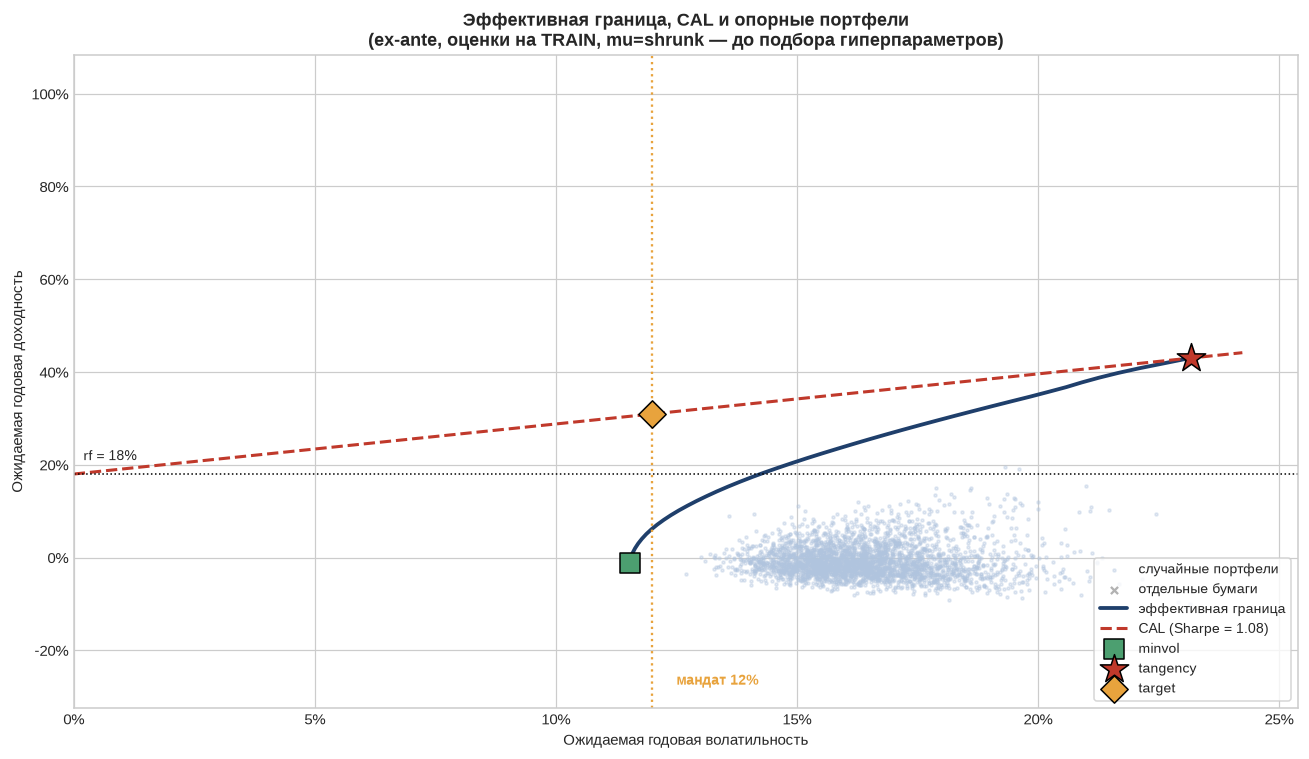

In [14]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(cloud["vol"], cloud["ret"], s=4, c="lightsteelblue", alpha=0.35,
           label="случайные портфели")
ax.scatter(np.sqrt(np.diag(S_train)), mu_train.values, s=22, c="grey", alpha=0.6,
           marker="x", label="отдельные бумаги")
ax.plot(frontier["vol"], frontier["ret"], lw=2.5, color="#1f3f6b", label="эффективная граница")

tp = tangency.expected_performance_
x_cal = np.linspace(0, frontier["vol"].max() * 1.05, 50)
ax.plot(x_cal, RISK_FREE_RATE + (tp["risky_ret"] - RISK_FREE_RATE) / tp["risky_vol"] * x_cal,
        ls="--", lw=2, color="#c0392b",
        label=f"CAL (Sharpe = {tp['risky_sharpe']:.2f})")

for strat, color, marker in [(minvol, "#4c9f70", "s"), (tangency, "#c0392b", "*"),
                             (target_demo, "#e8a33d", "D")]:
    ep = strat.expected_performance_
    ax.scatter(ep["exp_vol"], ep["exp_ret"], s=380 if marker == "*" else 160,
               c=color, edgecolor="k", zorder=5, marker=marker, label=strat.name)

ax.axhline(RISK_FREE_RATE, ls=":", c="k", lw=1)
ax.annotate(f"rf = {RISK_FREE_RATE:.0%}", (0.002, RISK_FREE_RATE + 0.03), fontsize=9)
ax.axvline(TARGET_VOL_MANDATE, ls=":", c="#e8a33d", lw=1.5)
ax.annotate(f"мандат {TARGET_VOL_MANDATE:.0%}", (TARGET_VOL_MANDATE + 0.005, ax.get_ylim()[0] + 0.05),
            fontsize=9, color="#e8a33d", fontweight="bold")
ax.set_xlim(0, frontier["vol"].max() * 1.1)
ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)
ax.set_xlabel("Ожидаемая годовая волатильность"); ax.set_ylabel("Ожидаемая годовая доходность")
ax.set_title("Эффективная граница, CAL и опорные портфели\n"
             "(ex-ante, оценки на TRAIN, mu=shrunk — до подбора гиперпараметров)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

Здесь видна типичная ошибка оптимизации на исторических данных: портфель максимальной
доходности на риск обещает доходность в разы выше безрисковой ставки (см. вывод ячейки выше)
при умеренной волатильности, хотя сам рынок за этот же период почти не рос. Это происходит
потому, что оптимизатор слишком доверяет случайным колебаниям исторических данных.

Такая красивая цифра — это ожидания, посчитанные на тех же данных, на которых портфель
и подбирался, а не реальный прогноз на будущее. Именно поэтому уровень риска нужно проверять
на данных, которые модель раньше не видела, — этим и займёмся дальше.

## 4. Бэктестер: walk-forward без утечек

Правила: веса портфеля на каждую дату пересчитываются только по ценам, известным
до этой даты (без заглядывания в будущее), затем применяются к доходности следующего дня
и держатся неизменными 21 день. При каждой ребалансировке платим издержки — 10 б.п. от
объёма сделок, то есть от того, насколько сильно новые веса отличаются от старых. Деньги,
не вложенные в акции, лежат в кэше (денежном рынке) под 18% годовых.

In [ ]:
@dataclass
class BacktestResult:
    returns: pd.Series
    weights: pd.DataFrame            # фактические (дрейфующие) веса по дням
    turnover: pd.Series              # оборот в момент каждой ребалансировки, доля капитала
    label: str = ""
    targets: pd.DataFrame = field(default=None, repr=False)   # целевые веса на ребалансировках

    @property
    def equity(self) -> pd.Series:
        return (1 + self.returns).cumprod()

    @property
    def drawdown(self) -> pd.Series:
        eq = self.equity
        return eq / eq.cummax() - 1

    @property
    def exposure(self) -> pd.Series:
        return self.weights.sum(axis=1)

    def metrics(self, rf: float = RISK_FREE_RATE) -> dict:
        r = self.returns
        eq = self.equity
        n = len(r)
        total = eq.iloc[-1] - 1
        cagr = (1 + total) ** (TRADING_DAYS / n) - 1
        vol = r.std() * np.sqrt(TRADING_DAYS)
        downside = r[r < 0].std() * np.sqrt(TRADING_DAYS)
        mdd = self.drawdown.min()
        var95 = np.percentile(r, 5)
        return {
            "total_return": total,
            "cagr": cagr,
            "ann_vol": vol,
            "sharpe": (cagr - rf) / vol if vol > 1e-9 else np.nan,
            "sortino": (cagr - rf) / downside if downside and downside > 1e-9 else np.nan,
            "max_dd": mdd,
            "calmar": cagr / abs(mdd) if mdd < -1e-9 else np.nan,
            "var_95_1d": var95,
            "cvar_95_1d": r[r <= var95].mean(),
            "hit_ratio": (r > 0).mean(),
            "avg_exposure": self.exposure.mean() if len(self.weights) else 0.0,
            "max_exposure": self.exposure.max() if len(self.weights) else 0.0,
            "turnover_total": self.turnover.sum(),
            "n_days": n,
        }


def walk_forward_backtest(weight_fn, prices: pd.DataFrame, start: int, end: int,
                          rebalance: int = REBALANCE_DAYS, lookback=LOOKBACK,
                          cost_bps: float = COST_BPS, rf_daily: float = RF_DAILY,
                          label: str = "") -> BacktestResult:
    """Walk-forward бэктест с учётом стоимости позиций.

    Портфель ведётся в деньгах (начальный капитал = 1.0): между ребалансировками веса
    свободно дрейфуют вместе с ценами, свободный остаток лежит в денежном рынке под rf.
    Веса на дату ребалансировки считаются по `prices.iloc[lo:i]` -- строго до этой даты,
    поэтому look-ahead невозможен. Издержки списываются с оборота в момент сделки.
    """
    ret = prices.pct_change().fillna(0.0)
    dates = prices.index
    holdings = pd.Series(0.0, index=prices.columns)     # стоимость позиций
    cash, equity_prev = 1.0, 1.0
    daily, w_hist, turn, targets = [], {}, {}, {}

    for i in range(start, end):
        # 1) ребалансировка по данным, известным до дня i
        if (i - start) % rebalance == 0:
            total = float(holdings.sum()) + cash
            lo = 0 if lookback is None else max(0, i - lookback)
            target_w = weight_fn(prices.iloc[lo:i]).reindex(prices.columns).fillna(0.0)
            target_val = target_w * total
            traded = float((target_val - holdings).abs().sum())
            cost = traded * cost_bps / 1e4
            # комиссия списывается ДО инвестирования, иначе у полностью вложенного
            # портфеля кэш уходит в минус и экспозиция формально превышает 100%
            holdings = target_w * (total - cost)
            cash = total - cost - float(holdings.sum())
            turn[dates[i]] = traded / total if total > 0 else 0.0
            targets[dates[i]] = target_w

        # 2) переоценка за день i
        holdings = holdings * (1.0 + ret.iloc[i])
        cash *= (1.0 + rf_daily)
        total = float(holdings.sum()) + cash
        daily.append(total / equity_prev - 1.0)
        equity_prev = total
        w_hist[dates[i]] = holdings / total

    res = BacktestResult(
        returns=pd.Series(daily, index=dates[start:end], name="return"),
        weights=pd.DataFrame(w_hist).T,
        turnover=pd.Series(turn, dtype=float),
        label=label,
    )
    res.targets = pd.DataFrame(targets).T
    return res


def run_on(split: str, weight_fn, label: str = "", **kw) -> BacktestResult:
    a, b = SPLITS[split]
    return walk_forward_backtest(weight_fn, prices, a, b, label=label, **kw)


# санитарная проверка бэктестера: 100% кэш должен дать ровно безрисковую доходность
_check = run_on("VALID", cash_only_fn, "cash")
print(f"Проверка: портфель из 100% кэша на VALID -> {_check.metrics()['cagr']:.2%} годовых "
      f"(ожидаем {RISK_FREE_RATE:.2%}); волатильность {_check.metrics()['ann_vol']:.4%}")

## 5. Уровень риска как гиперпараметр: подбор на TUNE

Перебираем разные комбинации настроек:

* `target_vol` — целевой уровень риска: 4%, 6%, 8%, 10%, 12%, 15%, 18%, 22%, 26% или 30%;
* `mu_method` — способ оценки ожидаемой доходности: hist, ema, shrunk или capm;
* `use_cash` — держим ли часть денег в кэше (True) или вкладываем всё в акции (False).

Для каждой комбинации смотрим два числа: чего мы ожидали заранее (по обучающим данным TRAIN)
и что реально получилось бы, если проиграть стратегию вперёд по времени на данных TUNE.
Лучшую комбинацию выбираем по правилам мандата (см. ниже), а данные VALID при этом
не используем вообще — они остаются для финальной проверки.

In [16]:
TARGET_VOL_GRID = [0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.18, 0.22, 0.26, 0.30]
MU_METHODS = ["hist", "ema", "shrunk", "capm"]
USE_CASH_GRID = [True, False]

grid_rows, tune_results = [], {}
for mu_m, use_cash, tv in itertools.product(MU_METHODS, USE_CASH_GRID, TARGET_VOL_GRID):
    params = dict(target_vol=tv, mu_method=mu_m, use_cash=use_cash,
                  gamma=0.5, cov_method="ledoit_wolf")
    key = f"{mu_m}|{'CAL' if use_cash else 'equity'}|{tv:.2f}"

    ex_ante = ClassicPortfolioStrategy(**params).fit(train_prices).expected_performance_
    fn = weight_fn_factory(**params)
    bt = run_on("TUNE", fn, label=key)
    tune_results[key] = bt
    m = bt.metrics()
    n_fallback = sum(1 for f in fn.fallbacks if f)
    grid_rows.append({
        "key": key, "mu_method": mu_m, "mode": "CAL" if use_cash else "equity",
        "target_vol": tv,
        "exante_ret": ex_ante["exp_ret"], "exante_vol": ex_ante["exp_vol"],
        "risky_share": ex_ante["risky_share"], "n_pos": ex_ante["n_positions"],
        "tune_cagr": m["cagr"], "tune_vol": m["ann_vol"], "tune_sharpe": m["sharpe"],
        "tune_mdd": m["max_dd"], "tune_total": m["total_return"],
        "vol_error": m["ann_vol"] - tv,
        "fallbacks": f"{n_fallback}/{len(fn.fallbacks)}",
    })

grid = pd.DataFrame(grid_rows)
print(f"Протестировано конфигураций: {len(grid)}")
print("\nЛучшие 12 по Sharpe на TUNE:")
print(grid.sort_values("tune_sharpe", ascending=False)
      .head(12)[["key", "tune_cagr", "tune_vol", "tune_sharpe", "tune_mdd", "risky_share", "n_pos", "fallbacks"]]
      .round(3).to_string(index=False))

Протестировано конфигураций: 80

Лучшие 12 по Sharpe на TUNE:
             key  tune_cagr  tune_vol  tune_sharpe  tune_mdd  risky_share  n_pos fallbacks
 ema|equity|0.15      0.150     0.276       -0.108    -0.116          1.0     21       0/2
 ema|equity|0.12      0.135     0.253       -0.180    -0.104          1.0     30       0/2
 ema|equity|0.18      0.072     0.288       -0.375    -0.128          1.0     18       0/2
 ema|equity|0.26      0.019     0.348       -0.464    -0.148          1.0      7       0/2
 ema|equity|0.22     -0.003     0.323       -0.567    -0.149          1.0     13       0/2
 ema|equity|0.30     -0.039     0.358       -0.612    -0.154          1.0      7       0/2
hist|equity|0.22     -0.390     0.309       -1.848    -0.147          1.0     15       0/2
   hist|CAL|0.22     -0.368     0.296       -1.850    -0.138          1.0     22       0/2
    ema|CAL|0.12     -0.237     0.223       -1.864    -0.100          1.0     65       1/2
   hist|CAL|0.26     -0.392 

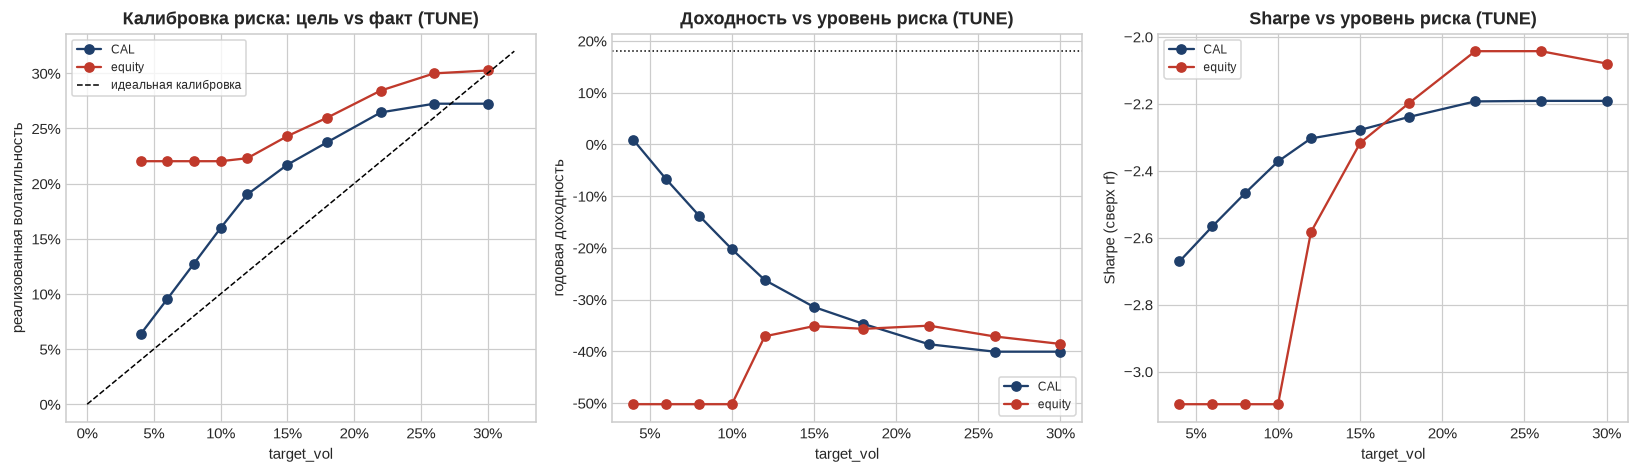

In [17]:
# насколько точно модель попадает в заданный уровень риска
calib = (grid.groupby(["mode", "target_vol"])[["tune_vol", "tune_cagr", "tune_sharpe"]]
         .mean().reset_index())
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for mode, c in [("CAL", "#1f3f6b"), ("equity", "#c0392b")]:
    sub = calib[calib["mode"] == mode]
    axes[0].plot(sub["target_vol"], sub["tune_vol"], "o-", color=c, label=mode)
    axes[1].plot(sub["target_vol"], sub["tune_cagr"], "o-", color=c, label=mode)
    axes[2].plot(sub["target_vol"], sub["tune_sharpe"], "o-", color=c, label=mode)

axes[0].plot([0, 0.32], [0, 0.32], ls="--", c="k", lw=1, label="идеальная калибровка")
axes[0].set_title("Калибровка риска: цель vs факт (TUNE)")
axes[0].set_xlabel("target_vol"); axes[0].set_ylabel("реализованная волатильность")
axes[1].axhline(RISK_FREE_RATE, ls=":", c="k", lw=1)
axes[1].set_title("Доходность vs уровень риска (TUNE)")
axes[1].set_xlabel("target_vol"); axes[1].set_ylabel("годовая доходность")
axes[2].set_title("Sharpe vs уровень риска (TUNE)")
axes[2].set_xlabel("target_vol"); axes[2].set_ylabel("Sharpe (сверх rf)")
for ax in axes:
    ax.xaxis.set_major_formatter(PCT)
    ax.legend(fontsize=8)
axes[0].yaxis.set_major_formatter(PCT); axes[1].yaxis.set_major_formatter(PCT)
plt.tight_layout(); plt.show()

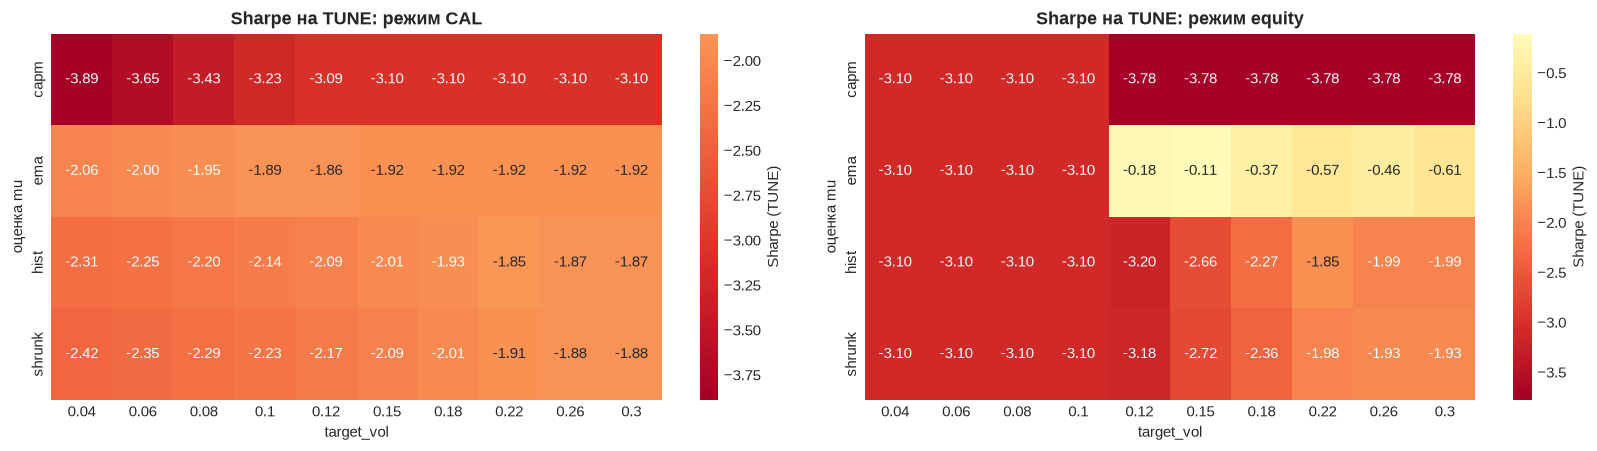

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, mode in zip(axes, ["CAL", "equity"]):
    piv = (grid[grid["mode"] == mode]
           .pivot_table(index="mu_method", columns="target_vol", values="tune_sharpe"))
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax,
                cbar_kws={"label": "Sharpe (TUNE)"})
    ax.set_title(f"Sharpe на TUNE: режим {mode}")
    ax.set_xlabel("target_vol"); ax.set_ylabel("оценка mu")
plt.tight_layout(); plt.show()

### 5.1 Правило выбора по мандату

Для достижения конкретного уровня доходности/риска, отбираем
победителя в три шага:

1. **Жёсткие ограничения:** просадка не глубже 15%, а реальная волатильность на TUNE
   должна попасть в коридор 8…16% (это целевые 12% плюс-минус 4 процентных пункта).
2. **Главный критерий — насколько точно попали в целевой риск 12%.** Побеждает та
   комбинация, чья реальная волатильность оказалась ближе всего к 12% (с точностью
   до 1 процентного пункта). Если выбирать иначе — например, просто «максимум доходности
   внутри коридора» — то на падающем рынке отбор всегда будет скатываться к нижней границе
   коридора, и заявленная цель в 12% риска так и не будет достигнута.
3. **Если несколько вариантов одинаково точно попали в цель — сравниваем по доходности**
   (а не по коэффициенту Шарпа, почему — ниже).

**Почему не по коэффициенту Шарпа.** Шарп — это доходность сверх безрисковой ставки,
делённая на волатильность. Проблема в том, что почти на всех наших бумагах (65 из 68)
доходность ниже безрисковой ставки 18%, то есть эта «доходность сверх ставки» — число
отрицательное. А когда числитель отрицательный, деление на меньшую волатильность даёт
более отрицательный, то есть худший, результат. Из-за этого при ранжировании по Шарпу
побеждают более рискованные и более убыточные портфели: например, из двух портфелей,
одинаково потерявших 10% сверх ставки, портфель с волатильностью 40% получит Шарп −0.25,
а портфель с волатильностью всего 5% — Шарп −2.0, то есть формально «хуже», хотя на деле
он безопаснее. Поэтому внутри уже отобранных по риску вариантов сравниваем просто по
доходности — здесь такой перекос не возникает. Ниже для сравнения выводится, что выбрал
бы критерий по Шарпу — разница хорошо видна.

In [ ]:
eligible = grid[grid["tune_mdd"] >= MAX_DD_MANDATE].copy()
eligible["vol_gap"] = (eligible["tune_vol"] - TARGET_VOL_MANDATE).abs()
eligible = eligible[eligible["vol_gap"] <= VOL_TOLERANCE]
# точность попадания в целевой риск, округлённая до 1 п.п.: попадания, различающиеся
# меньше чем на процентный пункт, считаем равными и разрешаем спор доходностью
eligible["vol_bucket"] = (eligible["vol_gap"] / 0.01).round().astype(int)

print(f"Конфигураций в коридоре риска {TARGET_VOL_MANDATE-VOL_TOLERANCE:.0%}...{TARGET_VOL_MANDATE+VOL_TOLERANCE:.0%} "
      f"и с просадкой не глубже {MAX_DD_MANDATE:.0%}: {len(eligible)} из {len(grid)}")
ranked = eligible.sort_values(["vol_bucket", "tune_cagr"], ascending=[True, False])
print(ranked.head(10)[["key", "tune_vol", "vol_gap", "tune_cagr", "tune_sharpe",
                       "tune_mdd", "fallbacks"]].round(3).to_string(index=False))

best = ranked.iloc[0]
by_sharpe = eligible.sort_values("tune_sharpe", ascending=False).iloc[0]
if by_sharpe["key"] != best["key"]:
    worse = (best["tune_cagr"] - by_sharpe["tune_cagr"]) * 100
    print(f"\nПроверка на патологию Sharpe: по Sharpe победил бы {by_sharpe['key']} "
          f"(доходность {by_sharpe['tune_cagr']:+.2%}, волатильность {by_sharpe['tune_vol']:.2%}, "
          f"Sharpe {by_sharpe['tune_sharpe']:.2f}),")
    print(f"                              то есть портфель "
          + (f"с доходностью на {worse:.1f} п.п. ниже" if worse > 0 else "не лучше по доходности")
          + " и волатильностью, отклоняющейся от цели на "
          f"{by_sharpe['vol_gap']*100:.1f} п.п. против {best['vol_gap']*100:.1f} п.п. у выбранного.")
BEST_PARAMS = dict(target_vol=float(best["target_vol"]),
                   mu_method=best["mu_method"],
                   use_cash=best["mode"] == "CAL",
                   gamma=0.5, cov_method="ledoit_wolf")
print("\n>>> Выбранная конфигурация:", BEST_PARAMS)
print(f">>> На TUNE: доходность {best['tune_cagr']:.2%} годовых, волатильность {best['tune_vol']:.2%} "
      f"(цель {TARGET_VOL_MANDATE:.0%}, промах {best['vol_gap']*100:.1f} п.п.), "
      f"Sharpe {best['tune_sharpe']:.2f}, макс. просадка {best['tune_mdd']:.2%}")

## 6. Тестирование на валидационном датасете

VALID — последние 25% истории — ни разу не использовались ни для оценки доходности и риска
бумаг, ни для подбора гиперпараметров. Проверяем на этих данных:

* три версии нашей модели с разным уровнем риска — консервативный (6%), сбалансированный
  (12%) и агрессивный (25%) — чтобы посмотреть, как уровень риска влияет на результат на
  новых данных; тот профиль, что совпал с конфигурацией, выбранной по мандату, помечен как
  «выбранный» (а если точного совпадения нет — выбранная конфигурация показана отдельной
  строкой);
* обычный портфель Марковица без кэша (все деньги в акциях) с целевым риском 15%;
* несколько простых стратегий для сравнения: равновзвешенный портфель с ребалансировкой,
  равновзвешенный портфель без ребалансировки (купил и держи), портфель минимальной
  волатильности и просто депозит (денежный рынок).

In [20]:
PROFILES = [("Консервативный", 0.06, "#4c9f70"),
            ("Сбалансированный", 0.12, "#e8a33d"),
            ("Агрессивный", 0.25, "#c0392b")]
best_tv = BEST_PARAMS["target_vol"]
is_best = lambda tv: abs(tv - best_tv) < 1e-9

PORTFOLIOS = {}
# если выбранный уровень риска не совпал ни с одним профилем -- он идёт отдельной строкой,
# иначе просто помечаем совпавший профиль как выбранный (без дублирования)
if not any(is_best(tv) for _, tv, _ in PROFILES):
    PORTFOLIOS[f"Выбранная (мандат, цель {best_tv:.0%})"] = dict(
        kind="strategy", params=BEST_PARAMS, color="#1f3f6b", lw=3)
for pname, ptv, pcolor in PROFILES:
    key = f"{pname} ({ptv:.0%})" + (" — выбранный" if is_best(ptv) else "")
    PORTFOLIOS[key] = dict(kind="strategy",
                           color="#1f3f6b" if is_best(ptv) else pcolor,
                           lw=3 if is_best(ptv) else 1.8,
                           params={**BEST_PARAMS, "target_vol": ptv})

SELECTED = next(k for k, v in PORTFOLIOS.items() if is_best(v["params"]["target_vol"]))

SHORT = {"Консервативный": "Консерв.", "Сбалансированный": "Сбаланс.",
         "Агрессивный": "Агресс.", "Марковиц без кэша": "Марковиц",
         "Equal-weight (ребаланс)": "EW реб.", "Equal-weight buy & hold": "EW b&h",
         "Min volatility": "MinVol", "Денежный рынок (18%)": "Кэш 18%",
         " — выбранный": "*"}

def short_name(name: str) -> str:
    """Компактная подпись для тесных панелей дашборда."""
    for long, brief in SHORT.items():
        name = name.replace(long, brief)
    return name


def pkey(prefix: str) -> str:
    """Ключ портфеля по префиксу имени -- имена содержат подставляемые проценты."""
    return next(k for k in PORTFOLIOS if k.startswith(prefix))

PORTFOLIOS |= {
    "Марковиц без кэша (15%)": dict(kind="strategy", color="#8e44ad", lw=1.6,
                                    params={**BEST_PARAMS, "target_vol": 0.15, "use_cash": False}),
    "Min volatility": dict(kind="strategy", color="#16a085", lw=1.4,
                           params={**BEST_PARAMS, "mode": "min_vol", "use_cash": False}),
    "Equal-weight (ребаланс)": dict(kind="fn", fn=equal_weight_fn, color="#7f8c8d", lw=1.6, ls="--"),
    "Equal-weight buy & hold": dict(kind="fn", fn=equal_weight_fn, color="#95a5a6", lw=1.4, ls=":",
                                    rebalance=10 ** 6),
    "Денежный рынок (18%)": dict(kind="fn", fn=cash_only_fn, color="#111111", lw=1.4, ls="-."),
}

def build_fn(spec):
    return weight_fn_factory(**spec["params"]) if spec["kind"] == "strategy" else spec["fn"]

results = {"TUNE": {}, "VALID": {}}
fallback_log = {}
for split in ["TUNE", "VALID"]:
    for name, spec in PORTFOLIOS.items():
        kw = {"rebalance": spec["rebalance"]} if "rebalance" in spec else {}
        fn = build_fn(spec)
        results[split][name] = run_on(split, fn, label=name, **kw)
        if spec["kind"] == "strategy":
            fallback_log[(split, name)] = [f for f in fn.fallbacks if f]

n_fb = sum(len(fb) for fb in fallback_log.values())
if n_fb:
    print("Диагностика оптимизатора (сколько ребалансировок ушло в fallback -> min_volatility):")
    for (split, name), fb in fallback_log.items():
        if fb:
            print(f"  {split:<6} {name:<30} {len(fb)}/{len(results[split][name].turnover)}  {set(fb)}")
else:
    print("Диагностика оптимизатора: откатов к min_volatility не потребовалось — "
          "исходная задача решалась на каждой ребалансировке.")
print()

valid_metrics = pd.DataFrame({n: r.metrics() for n, r in results["VALID"].items()}).T
tune_metrics = pd.DataFrame({n: r.metrics() for n, r in results["TUNE"].items()}).T

show_cols = ["total_return", "cagr", "ann_vol", "sharpe", "sortino", "max_dd", "calmar",
             "var_95_1d", "hit_ratio", "avg_exposure", "turnover_total"]
print("=" * 110)
print("РЕЗУЛЬТАТЫ НА ВАЛИДАЦИОННОМ ДАТАСЕТЕ "
      f"({prices.index[SPLITS['VALID'][0]]:%Y-%m-%d} ... {prices.index[SPLITS['VALID'][1]-1]:%Y-%m-%d}, "
      f"{SPLITS['VALID'][1]-SPLITS['VALID'][0]} дней)")
print("=" * 110)
print(valid_metrics[show_cols].round(3).to_string())

Диагностика оптимизатора (сколько ребалансировок ушло в fallback -> min_volatility):
  TUNE   Консервативный (6%) — выбранный 1/2  {'OptimizationError'}
  TUNE   Сбалансированный (12%)         1/2  {'OptimizationError'}
  TUNE   Агрессивный (25%)              1/2  {'OptimizationError'}

РЕЗУЛЬТАТЫ НА ВАЛИДАЦИОННОМ ДАТАСЕТЕ (2024-09-06 ... 2024-12-03, 63 дней)
                                 total_return   cagr  ann_vol  sharpe  sortino  max_dd  calmar  var_95_1d  hit_ratio  avg_exposure  turnover_total
Консервативный (6%) — выбранный        -0.026 -0.099    0.089  -3.146   -6.058  -0.066  -1.498     -0.009      0.429         0.278           1.160
Сбалансированный (12%)                 -0.091 -0.316    0.178  -2.792   -5.410  -0.155  -2.045     -0.017      0.429         0.556           2.337
Агрессивный (25%)                      -0.195 -0.581    0.293  -2.601   -4.983  -0.269  -2.158     -0.030      0.429         0.939           3.747
Марковиц без кэша (15%)                -0.135 -0.4

In [21]:
def fmt_table(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["Доходность за период"] = df["total_return"].map("{:+.2%}".format)
    out["Годовых"] = df["cagr"].map("{:+.1%}".format)
    out["Волатильность"] = df["ann_vol"].map("{:.1%}".format)
    out["Sharpe"] = df["sharpe"].map("{:.2f}".format)
    out["Sortino"] = df["sortino"].map("{:.2f}".format)
    out["Макс. просадка"] = df["max_dd"].map("{:.1%}".format)
    out["VaR 95% (1д)"] = df["var_95_1d"].map("{:.2%}".format)
    out["Доля в акциях"] = df["avg_exposure"].map("{:.0%}".format)
    return out

print("TUNE:")
print(fmt_table(tune_metrics).to_string())
print("\nVALID:")
print(fmt_table(valid_metrics).to_string())

TUNE:
                                Доходность за период Годовых Волатильность Sharpe Sortino Макс. просадка VaR 95% (1д) Доля в акциях
Консервативный (6%) — выбранный               -0.74%   -4.8%         11.4%  -2.00   -2.76          -4.8%       -1.49%           47%
Сбалансированный (12%)                        -3.99%  -23.7%         22.3%  -1.86   -2.50         -10.0%       -2.98%           93%
Агрессивный (25%)                             -5.09%  -29.3%         24.6%  -1.92   -2.49         -11.9%       -3.11%          100%
Марковиц без кэша (15%)                       +2.13%  +15.0%         27.6%  -0.11   -0.16         -11.6%       -2.61%          100%
Min volatility                                -9.99%  -50.2%         22.0%  -3.10   -4.58         -15.7%       -2.79%          100%
Equal-weight (ребаланс)                       -8.88%  -46.0%         24.3%  -2.64   -4.03         -16.6%       -2.92%          100%
Equal-weight buy & hold                       -8.84%  -45.9%         2

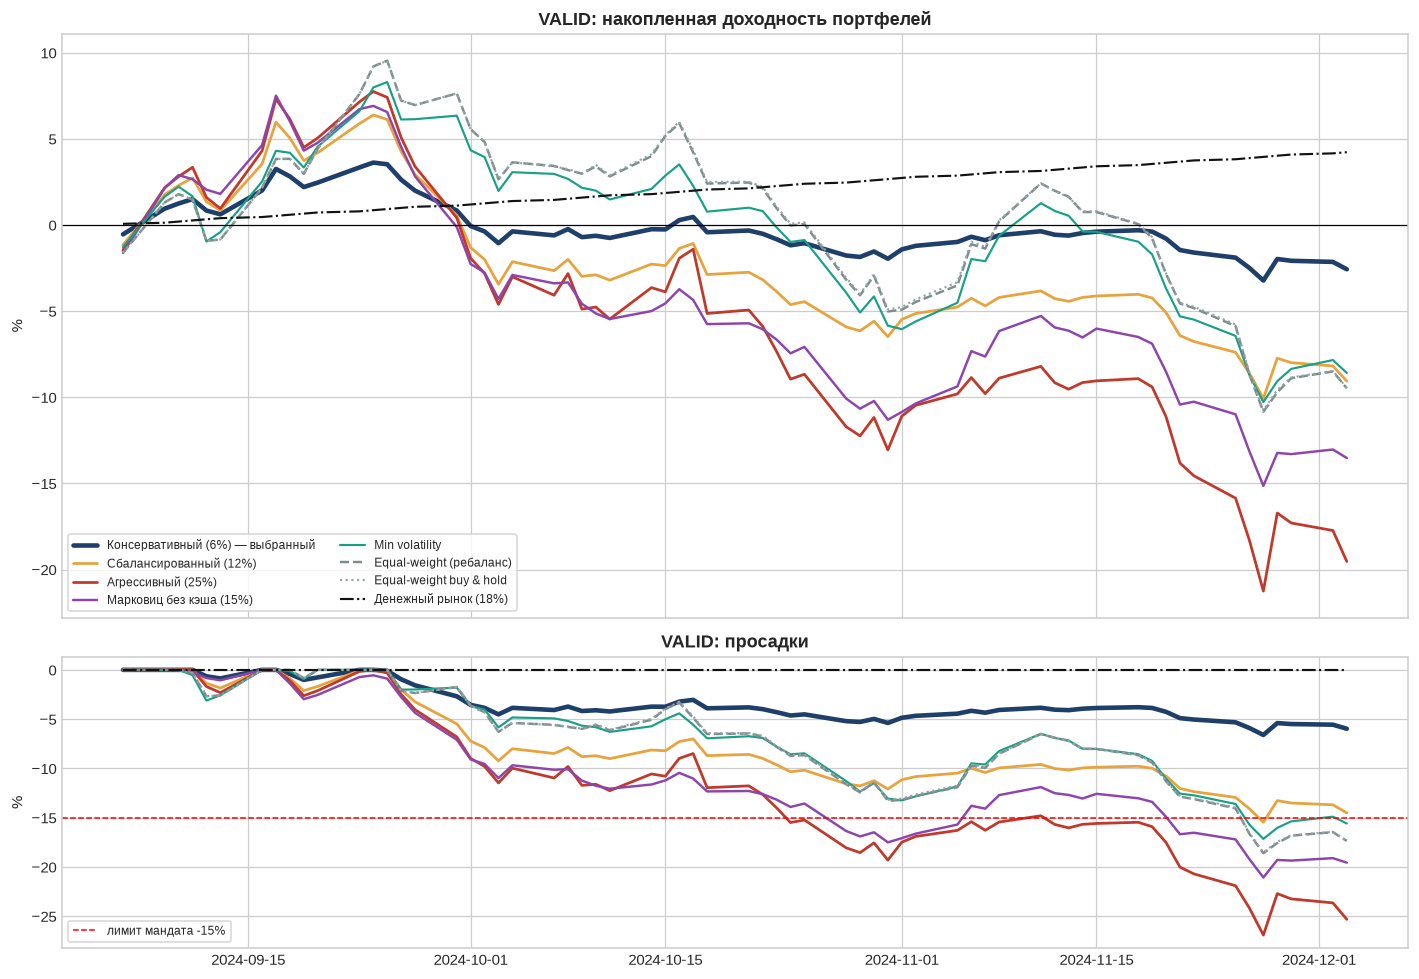

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
for name, res in results["VALID"].items():
    spec = PORTFOLIOS[name]
    eq = (res.equity - 1) * 100
    axes[0].plot(eq.index, eq.values, label=name, color=spec["color"],
                 lw=spec["lw"], ls=spec.get("ls", "-"))
    axes[1].plot(res.drawdown.index, res.drawdown.values * 100, color=spec["color"],
                 lw=spec["lw"], ls=spec.get("ls", "-"))
axes[0].axhline(0, c="k", lw=0.8)
axes[0].set_title("VALID: накопленная доходность портфелей")
axes[0].set_ylabel("%")
axes[0].legend(fontsize=8, ncol=2, loc="lower left")
axes[1].set_title("VALID: просадки")
axes[1].set_ylabel("%")
axes[1].axhline(MAX_DD_MANDATE * 100, ls="--", c="r", lw=1, label="лимит мандата -15%")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

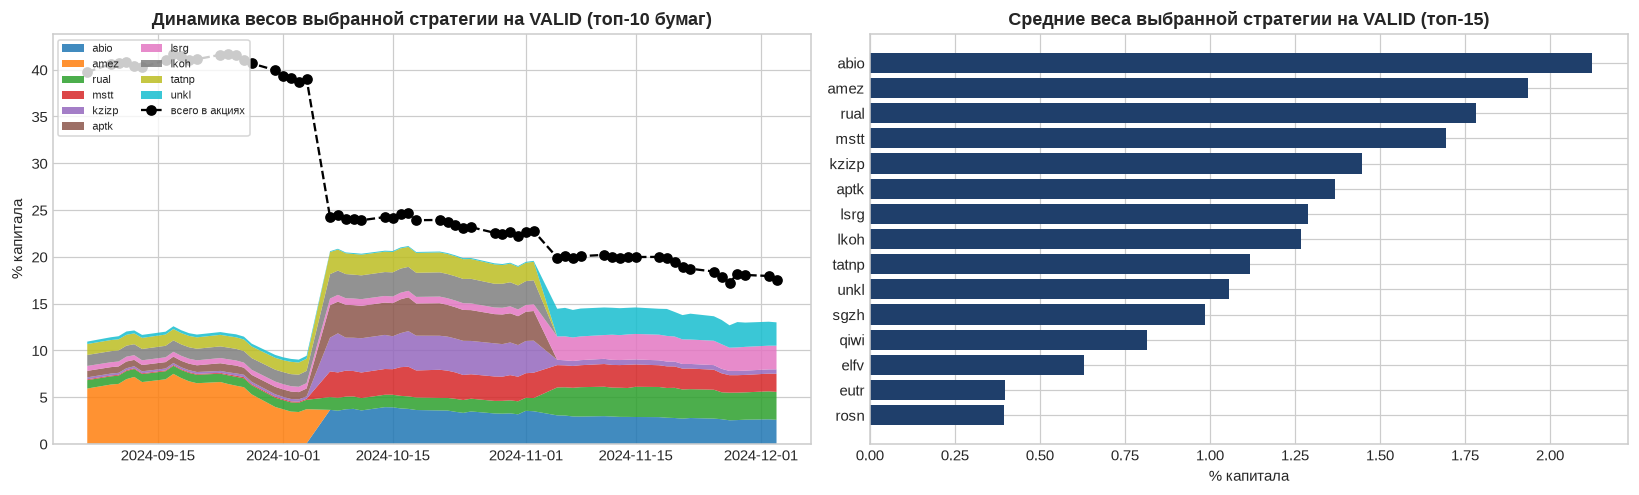

Оборот на каждой ребалансировке (доля капитала, прошедшая через сделки):
2024-09-06    40.1%
2024-10-07    49.6%
2024-11-05    26.3%


In [23]:
# что выбранная стратегия делала с экспозицией и весами на VALID
best_res = results["VALID"][SELECTED]
wh = best_res.weights
top_names = wh.mean().sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
axes[0].stackplot(wh.index, [wh[c].values * 100 for c in top_names],
                  labels=list(top_names), alpha=0.85)
axes[0].plot(best_res.exposure.index, best_res.exposure.values * 100, "ko--", lw=1.5,
             label="всего в акциях")
axes[0].set_title("Динамика весов выбранной стратегии на VALID (топ-10 бумаг)")
axes[0].set_ylabel("% капитала")
axes[0].legend(fontsize=7, ncol=2, loc="upper left")

wmean = wh.mean()
wmean = wmean[wmean > 1e-4].sort_values(ascending=False).head(15)
axes[1].barh(wmean.index[::-1], wmean.values[::-1] * 100, color="#1f3f6b")
axes[1].set_title("Средние веса выбранной стратегии на VALID (топ-15)")
axes[1].set_xlabel("% капитала")
plt.tight_layout(); plt.show()

print("Оборот на каждой ребалансировке (доля капитала, прошедшая через сделки):")
print(best_res.turnover.map("{:.1%}".format).to_string())

### 6.1 Практическая аллокация: во что вложить 1 000 000 ₽

Веса портфеля — это доли капитала, а не реальный список покупок. Чтобы получить конкретный
ордер на покупку, переводим эти доли в целое число лотов по последним ценам акций
(с помощью `DiscreteAllocation.lp_portfolio`). Деньги, которые не удалось разложить по акциям
ровными лотами, остаются в кэше (денежном рынке).

In [24]:
final_strategy = ClassicPortfolioStrategy(**BEST_PARAMS, name="final").fit(prices)
print(final_strategy.summary())
if final_strategy.fallback_:
    print("ВНИМАНИЕ: на полной истории max_sharpe неразрешим (ни одна бумага не обгоняет ставку 18%),\n"
          "          поэтому рисковое ядро = портфель минимальной волатильности, "
          f"масштабированный до риска {BEST_PARAMS['target_vol']:.0%}.")

MIN_POSITION = 0.005          # позиции меньше 0.5% капитала не покупаем (транзакционная гигиена)

risky_share = float(final_strategy.weights_.sum())
risky_w = final_strategy.weights_[final_strategy.weights_ >= MIN_POSITION * risky_share]
risky_w = risky_w / risky_w.sum()
print(f"Позиций в модели: {(final_strategy.weights_ > 1e-4).sum()}, "
      f"после отсечения мелких (<{MIN_POSITION:.1%}): {len(risky_w)}")

latest = get_latest_prices(prices)[risky_w.index]     # выравниваем цены с тикерами портфеля
alloc, leftover = DiscreteAllocation(
    risky_w.to_dict(), latest, total_portfolio_value=PORTFOLIO_VALUE * risky_share
).lp_portfolio()

alloc_df = pd.DataFrame({
    "лотов": pd.Series(alloc),
    "цена": pd.Series({t: latest[t] for t in alloc}),
})
alloc_df["сумма, ₽"] = (alloc_df["лотов"] * alloc_df["цена"]).round(0)
alloc_df["доля портфеля"] = (alloc_df["сумма, ₽"] / PORTFOLIO_VALUE).map("{:.2%}".format)
alloc_df = alloc_df.sort_values("сумма, ₽", ascending=False)
print(f"\nПортфель на {prices.index[-1]:%Y-%m-%d} для {PORTFOLIO_VALUE:,.0f} ₽ "
      f"(в акциях {risky_share:.1%}):")
print(alloc_df.to_string())
cash_rub = PORTFOLIO_VALUE - alloc_df["сумма, ₽"].sum()
print(f"\nВ акциях: {alloc_df['сумма, ₽'].sum():,.0f} ₽ | "
      f"в денежном рынке (включая нераспределённый остаток {leftover:,.0f} ₽): {cash_rub:,.0f} ₽")

final: mode=target_risk, target_vol=6%, mu=ema, cash=60% | ex-ante ret=-3.6%, vol=6.0%, sharpe=-3.61, позиций=60 [fallback: OptimizationError]
ВНИМАНИЕ: на полной истории max_sharpe неразрешим (ни одна бумага не обгоняет ставку 18%),
          поэтому рисковое ядро = портфель минимальной волатильности, масштабированный до риска 6%.
Позиций в модели: 60, после отсечения мелких (<0.5%): 51

Портфель на 2024-12-03 для 1,000,000 ₽ (в акциях 39.7%):
       лотов        цена  сумма, ₽ доля портфеля
lkoh       2   6823.0000   13646.0         1.36%
lsngp     65    192.4500   12509.0         1.25%
rosn      25    493.4000   12335.0         1.23%
lnzl       1  12100.0000   12100.0         1.21%
elfv   24643      0.4898   12070.0         1.21%
trnfp     12   1005.5000   12066.0         1.21%
nvtk      14    847.6000   11866.0         1.19%
rual     328     35.9200   11782.0         1.18%
tatnp     21    550.4000   11558.0         1.16%
gmkn      97    114.3400   11091.0         1.11%
moex      56

## 7. Дашборд эффективности портфелей по критерию риск/доходность

Сначала прогоняем на данных VALID все уровни риска из нашей сетки (для выбранного способа
оценки доходности, в двух режимах — с кэшем и без). Так получаем реальную кривую
«риск/доходность», уже проверенную на новых данных, и сравниваем её с тем, что модель
обещала заранее (ex-ante).

In [25]:
risk_curve_rows = []
for use_cash in [True, False]:
    for tv in TARGET_VOL_GRID:
        params = {**BEST_PARAMS, "target_vol": tv, "use_cash": use_cash}
        ex = ClassicPortfolioStrategy(**params).fit(train_prices).expected_performance_
        m_tune = tune_results[f"{BEST_PARAMS['mu_method']}|{'CAL' if use_cash else 'equity'}|{tv:.2f}"].metrics()
        m_val = run_on("VALID", weight_fn_factory(**params)).metrics()
        risk_curve_rows.append({
            "mode": "CAL" if use_cash else "equity", "target_vol": tv,
            "exante_ret": ex["exp_ret"], "exante_vol": ex["exp_vol"],
            "risky_share": ex["risky_share"],
            "tune_ret": m_tune["cagr"], "tune_vol": m_tune["ann_vol"], "tune_sharpe": m_tune["sharpe"],
            "valid_ret": m_val["cagr"], "valid_vol": m_val["ann_vol"], "valid_sharpe": m_val["sharpe"],
            "valid_mdd": m_val["max_dd"], "valid_total": m_val["total_return"],
        })
# эффективная граница на ТОЙ ЖЕ оценке mu, что у выбранной модели: иначе панель 3
# сравнивала бы кривые модели с границей, построенной на другой оценке mu
frontier_model = efficient_frontier_points(
    estimate_mu(train_prices, BEST_PARAMS["mu_method"]), S_train)

risk_curve = pd.DataFrame(risk_curve_rows)

# коэффициент калибровки: считаем только по ненасыщенным уровням (где ещё есть кэш,
# т.е. модель физически способна попасть в цель)
unsat = risk_curve[(risk_curve["mode"] == "CAL") & (risk_curve["risky_share"] < 0.999)]
if len(unsat):
    print(f"Калибровка риска (CAL, ненасыщенные уровни): факт/цель = "
          f"{(unsat['valid_vol'] / unsat['target_vol']).mean():.2f}x на VALID, "
          f"{(unsat['tune_vol'] / unsat['target_vol']).mean():.2f}x на TUNE\n")

print("Реализованные характеристики по уровням риска на VALID:")
print(risk_curve[["mode", "target_vol", "risky_share", "valid_total", "valid_ret",
                  "valid_vol", "valid_sharpe", "valid_mdd"]].round(3).to_string(index=False))

Калибровка риска (CAL, ненасыщенные уровни): факт/цель = 1.48x на VALID, 1.90x на TUNE

Реализованные характеристики по уровням риска на VALID:
  mode  target_vol  risky_share  valid_total  valid_ret  valid_vol  valid_sharpe  valid_mdd
   CAL        0.04        0.347       -0.003     -0.014      0.059        -3.276     -0.035
   CAL        0.06        0.520       -0.026     -0.099      0.089        -3.146     -0.066
   CAL        0.08        0.694       -0.048     -0.178      0.118        -3.023     -0.096
   CAL        0.10        0.867       -0.069     -0.250      0.148        -2.904     -0.126
   CAL        0.12        1.000       -0.091     -0.316      0.178        -2.792     -0.155
   CAL        0.15        1.000       -0.122     -0.406      0.222        -2.635     -0.196
   CAL        0.18        1.000       -0.145     -0.465      0.241        -2.673     -0.219
   CAL        0.22        1.000       -0.175     -0.536      0.270        -2.650     -0.248
   CAL        0.26        1.

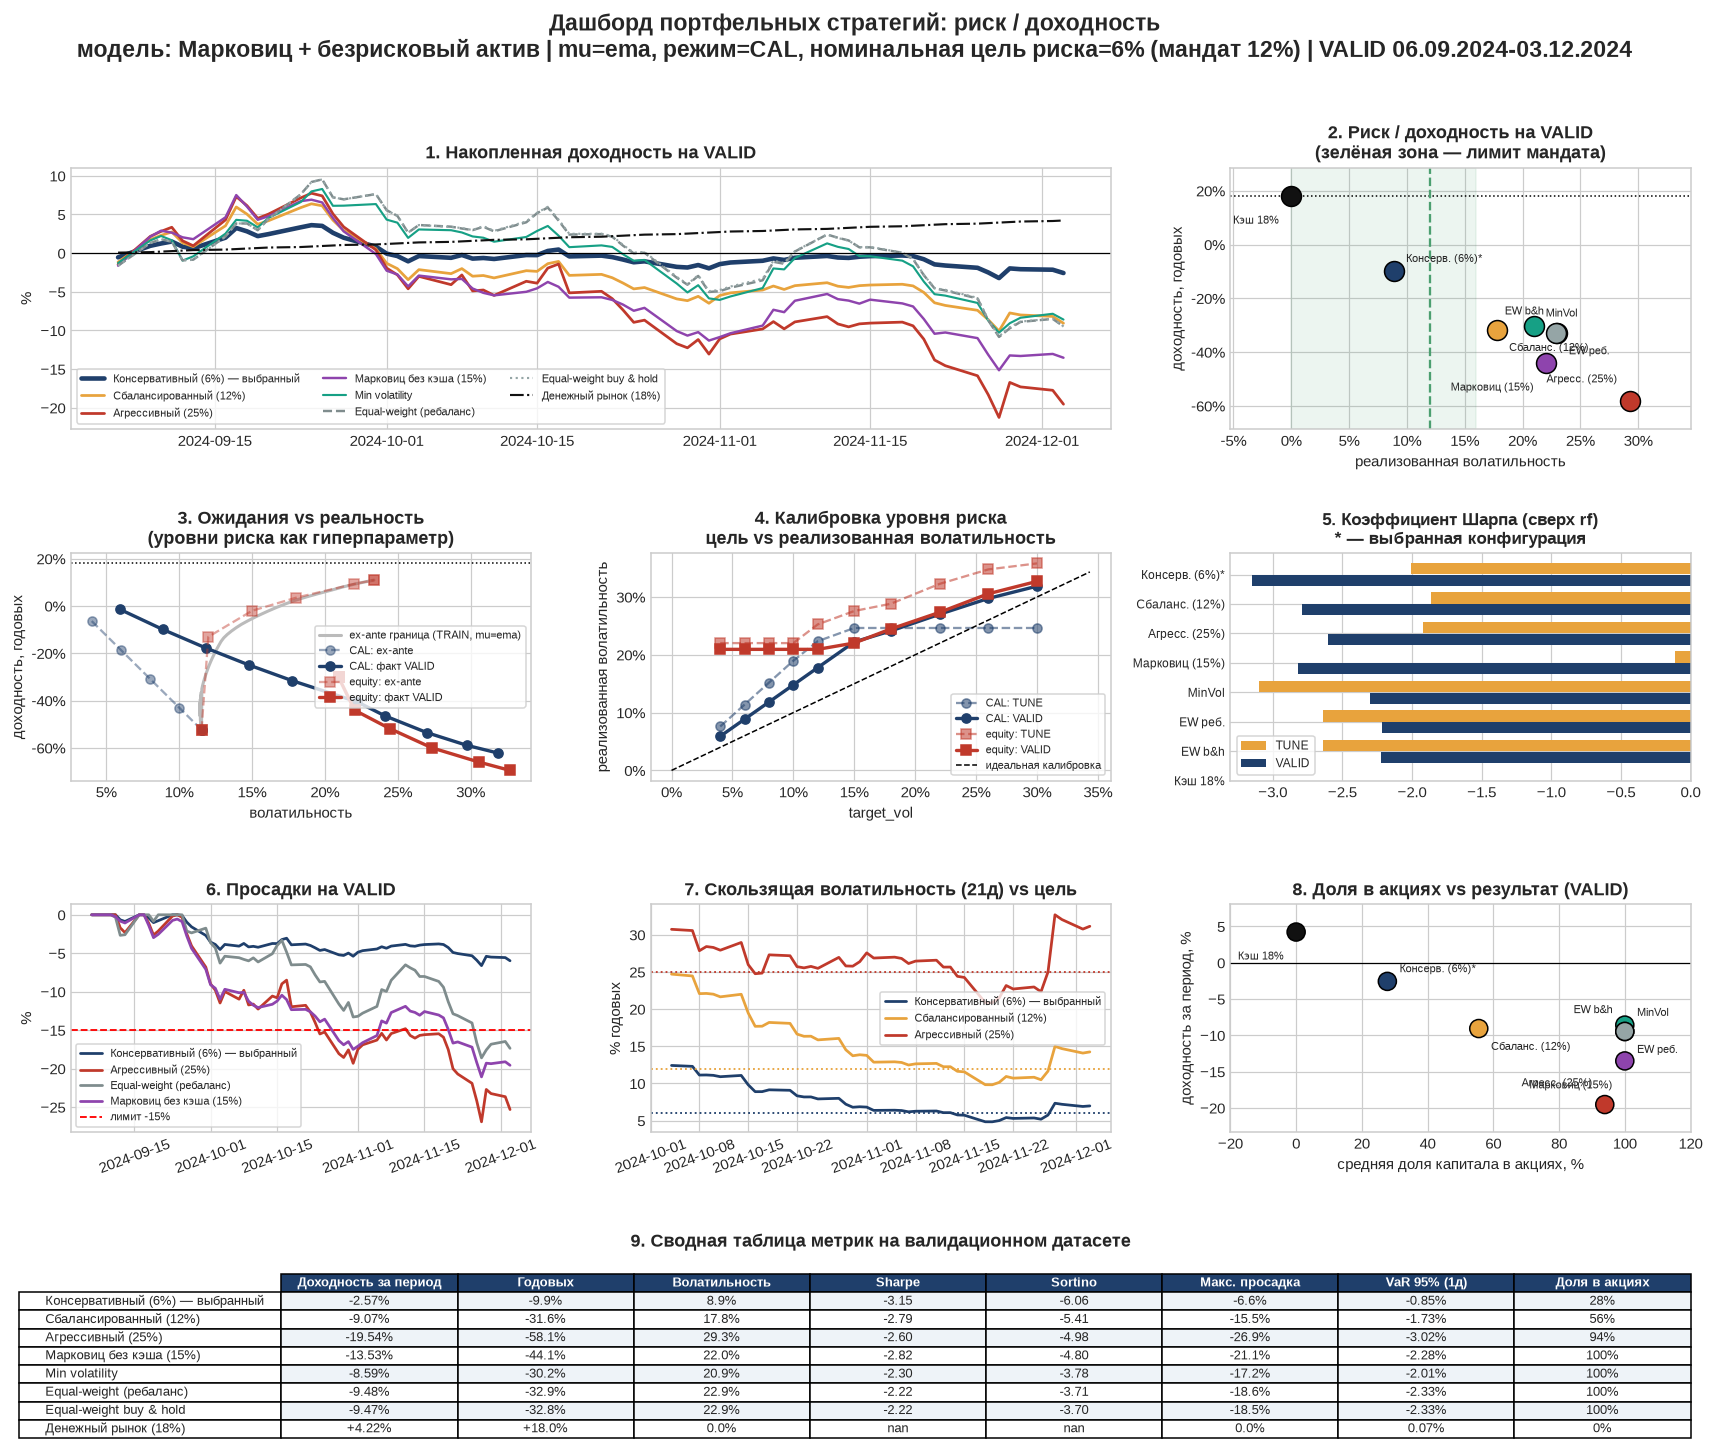

Дашборд сохранён в dashboard_risk_return.png


In [26]:
fig = plt.figure(figsize=(19, 15))
gs = GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.26,
              height_ratios=[1.15, 1, 1, 0.8])
fig.suptitle("Дашборд портфельных стратегий: риск / доходность\n"
             f"модель: Марковиц + безрисковый актив | mu={BEST_PARAMS['mu_method']}, "
             f"режим={'CAL' if BEST_PARAMS['use_cash'] else 'equity'}, "
             f"номинальная цель риска={BEST_PARAMS['target_vol']:.0%} "
             f"(мандат {TARGET_VOL_MANDATE:.0%}) | "
             f"VALID {prices.index[SPLITS['VALID'][0]]:%d.%m.%Y}-{prices.index[-1]:%d.%m.%Y}",
             fontsize=15, fontweight="bold", y=0.975)

# --- 1. накопленная доходность на VALID -----------------------------------------------
ax = fig.add_subplot(gs[0, :2])
for name, res in results["VALID"].items():
    spec = PORTFOLIOS[name]
    ax.plot(res.equity.index, (res.equity.values - 1) * 100, label=name,
            color=spec["color"], lw=spec["lw"], ls=spec.get("ls", "-"))
ax.axhline(0, c="k", lw=0.8)
ax.set_title("1. Накопленная доходность на VALID")
ax.set_ylabel("%")
ax.legend(fontsize=7.5, ncol=3, loc="lower left")

# --- 2. риск/доходность портфелей на VALID --------------------------------------------
ax = fig.add_subplot(gs[0, 2])
for j, (name, res) in enumerate(results["VALID"].items()):
    m = res.metrics()
    spec = PORTFOLIOS[name]
    ax.scatter(m["ann_vol"], m["cagr"], s=170, color=spec["color"], edgecolor="k", zorder=4)
    dx, dy = [(8, 6), (8, -14), (-8, 12), (-8, -18)][j % 4]
    ax.annotate(short_name(name), (m["ann_vol"], m["cagr"]), fontsize=7,
                ha="left" if dx > 0 else "right",
                xytext=(dx, dy), textcoords="offset points")
ax.axhline(RISK_FREE_RATE, ls=":", c="k", lw=1)
ax.axvspan(0, TARGET_VOL_MANDATE + VOL_TOLERANCE, color="#4c9f70", alpha=0.10)
ax.axvline(TARGET_VOL_MANDATE, ls="--", c="#4c9f70", lw=1.5)
ax.set_title("2. Риск / доходность на VALID\n(зелёная зона — лимит мандата)")
ax.margins(x=0.18, y=0.14)
ax.set_xlabel("реализованная волатильность"); ax.set_ylabel("доходность, годовых")
ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)

# --- 3. ex-ante граница vs реализованная ----------------------------------------------
ax = fig.add_subplot(gs[1, 0])
ax.plot(frontier_model["vol"], frontier_model["ret"], lw=2, color="#bbbbbb",
        label=f"ex-ante граница (TRAIN, mu={BEST_PARAMS['mu_method']})")
for mode, c, mk in [("CAL", "#1f3f6b", "o"), ("equity", "#c0392b", "s")]:
    sub = risk_curve[risk_curve["mode"] == mode]
    ax.plot(sub["exante_vol"], sub["exante_ret"], mk + "--", color=c, alpha=0.45,
            label=f"{mode}: ex-ante")
    ax.plot(sub["valid_vol"], sub["valid_ret"], mk + "-", color=c, lw=2.2,
            label=f"{mode}: факт VALID")
ax.axhline(RISK_FREE_RATE, ls=":", c="k", lw=1)
ax.set_title("3. Ожидания vs реальность\n(уровни риска как гиперпараметр)")
ax.set_xlabel("волатильность"); ax.set_ylabel("доходность, годовых")
ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)
ax.legend(fontsize=7)

# --- 4. калибровка риска ---------------------------------------------------------------
ax = fig.add_subplot(gs[1, 1])
for mode, c, mk in [("CAL", "#1f3f6b", "o"), ("equity", "#c0392b", "s")]:
    sub = risk_curve[risk_curve["mode"] == mode]
    ax.plot(sub["target_vol"], sub["tune_vol"], mk + "--", color=c, alpha=0.55, label=f"{mode}: TUNE")
    ax.plot(sub["target_vol"], sub["valid_vol"], mk + "-", color=c, lw=2.2, label=f"{mode}: VALID")
lim = max(risk_curve["target_vol"].max(), risk_curve["valid_vol"].max()) * 1.05
ax.plot([0, lim], [0, lim], ls="--", c="k", lw=1, label="идеальная калибровка")
ax.set_title("4. Калибровка уровня риска\nцель vs реализованная волатильность")
ax.set_xlabel("target_vol"); ax.set_ylabel("реализованная волатильность")
ax.xaxis.set_major_formatter(PCT); ax.yaxis.set_major_formatter(PCT)
ax.legend(fontsize=7)

# --- 5. Sharpe: TUNE vs VALID ----------------------------------------------------------
ax = fig.add_subplot(gs[1, 2])
names = list(PORTFOLIOS)
x = np.arange(len(names))
ax.barh(x - 0.2, [tune_metrics.loc[n, "sharpe"] for n in names], height=0.38,
        color="#e8a33d", label="TUNE")
ax.barh(x + 0.2, [valid_metrics.loc[n, "sharpe"] for n in names], height=0.38,
        color="#1f3f6b", label="VALID")
ax.set_yticks(x); ax.set_yticklabels([short_name(n) for n in names], fontsize=8)
ax.axvline(0, c="k", lw=0.8)
ax.set_title("5. Коэффициент Шарпа (сверх rf)\n* — выбранная конфигурация", fontsize=11)
ax.legend(fontsize=8)
ax.invert_yaxis()

# --- 6. просадки -----------------------------------------------------------------------
ax = fig.add_subplot(gs[2, 0])
for name in [SELECTED, pkey("Агрессивный"), pkey("Equal-weight (ребаланс)"),
             pkey("Марковиц без кэша")]:
    res = results["VALID"][name]
    ax.plot(res.drawdown.index, res.drawdown.values * 100, label=name,
            color=PORTFOLIOS[name]["color"], lw=1.8)
ax.axhline(MAX_DD_MANDATE * 100, ls="--", c="r", lw=1.2, label="лимит -15%")
ax.set_title("6. Просадки на VALID"); ax.set_ylabel("%")
ax.legend(fontsize=7)
ax.tick_params(axis="x", labelrotation=20)

# --- 7. риск-профиль: скользящая волатильность -----------------------------------------
ax = fig.add_subplot(gs[2, 1])
profile_names = [n for n in PORTFOLIOS if PORTFOLIOS[n]["kind"] == "strategy"
                 and "без кэша" not in n and "Min volatility" not in n]
for name in profile_names:
    res = results["VALID"][name]
    rv = res.returns.rolling(21).std() * np.sqrt(TRADING_DAYS)
    ax.plot(rv.index, rv.values * 100, label=name, color=PORTFOLIOS[name]["color"], lw=1.8)
    ax.axhline(PORTFOLIOS[name]["params"]["target_vol"] * 100, ls=":",
               c=PORTFOLIOS[name]["color"], lw=1.2)
ax.set_title("7. Скользящая волатильность (21д) vs цель")
ax.set_ylabel("% годовых")
ax.legend(fontsize=7)
ax.tick_params(axis="x", labelrotation=20)

# --- 8. вклад доходности: акции vs кэш -------------------------------------------------
ax = fig.add_subplot(gs[2, 2])
expo = [valid_metrics.loc[n, "avg_exposure"] for n in names]
tot = [valid_metrics.loc[n, "total_return"] for n in names]
sc = ax.scatter([e * 100 for e in expo], [t * 100 for t in tot],
                s=140, c=[PORTFOLIOS[n]["color"] for n in names], edgecolor="k", zorder=4)
for j, (n, e, t) in enumerate(zip(names, expo, tot)):
    dx, dy = [(8, 6), (8, -14), (-8, 12), (-8, -18)][j % 4]
    ax.annotate(short_name(n), (e * 100, t * 100), fontsize=7,
                ha="left" if dx > 0 else "right",
                xytext=(dx, dy), textcoords="offset points")
ax.axhline(0, c="k", lw=0.8)
ax.set_title("8. Доля в акциях vs результат (VALID)")
ax.set_xlabel("средняя доля капитала в акциях, %"); ax.set_ylabel("доходность за период, %")
ax.margins(x=0.20, y=0.16)

# --- 9. итоговая таблица ---------------------------------------------------------------
ax = fig.add_subplot(gs[3, :])
ax.axis("off")
tbl_df = fmt_table(valid_metrics)
tbl = ax.table(cellText=tbl_df.values, rowLabels=tbl_df.index, colLabels=tbl_df.columns,
               cellLoc="center", rowLoc="left", bbox=[0.13, 0.0, 0.87, 0.90])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for j in range(len(tbl_df.columns)):
    tbl[0, j].set_facecolor("#1f3f6b"); tbl[0, j].set_text_props(color="w", fontweight="bold")
for i in range(1, len(tbl_df.index) + 1):
    for j in range(len(tbl_df.columns)):
        tbl[i, j].set_facecolor("#eef3f8" if i % 2 else "w")
ax.set_title("9. Сводная таблица метрик на валидационном датасете", fontweight="bold", pad=6)

plt.savefig("dashboard_risk_return.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()
print("Дашборд сохранён в dashboard_risk_return.png")

### 7.1 Интерактивная версия дашборда (Plotly)

Тот же дашборд в интерактивном виде — с hover-подсказками по каждому портфелю.
Дополнительно сохраняется в самостоятельный файл `dashboard_risk_return.html`.

In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Риск / доходность портфелей (VALID)",
                    "Накопленная доходность (VALID)",
                    "Граница риск/доходность по уровням риска",
                    "Коэффициент Шарпа: TUNE vs VALID"),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "scatter"}, {"type": "bar"}]],
    horizontal_spacing=0.09, vertical_spacing=0.13,
)

for name, res in results["VALID"].items():
    m = res.metrics()
    dash.add_trace(go.Scatter(
        x=[m["ann_vol"]], y=[m["cagr"]], mode="markers+text", name=name,
        text=[short_name(name)], textposition="top center", textfont=dict(size=9),
        marker=dict(size=15, color=PORTFOLIOS[name]["color"],
                    line=dict(width=1, color="black")),
        hovertemplate=(f"<b>{name}</b><br>волатильность %{{x:.1%}}<br>доходность %{{y:.1%}}"
                       f"<br>Sharpe {m['sharpe']:.2f}<br>просадка {m['max_dd']:.1%}<extra></extra>"),
        showlegend=False), row=1, col=1)
dash.add_hline(y=RISK_FREE_RATE, line=dict(dash="dot", color="black"), row=1, col=1)
dash.add_vline(x=TARGET_VOL_MANDATE, line=dict(dash="dash", color="green"), row=1, col=1)

for name, res in results["VALID"].items():
    dash.add_trace(go.Scatter(
        x=res.equity.index, y=(res.equity.values - 1) * 100, name=name, legendgroup=name,
        line=dict(color=PORTFOLIOS[name]["color"], width=PORTFOLIOS[name]["lw"]),
        hovertemplate="%{x|%d.%m.%Y}<br>%{y:.2f}%<extra>" + name + "</extra>"),
        row=1, col=2)

for mode, c in [("CAL", "#1f3f6b"), ("equity", "#c0392b")]:
    sub = risk_curve[risk_curve["mode"] == mode]
    dash.add_trace(go.Scatter(x=sub["exante_vol"], y=sub["exante_ret"], mode="lines+markers",
                              name=f"{mode}: ex-ante", line=dict(color=c, dash="dash"),
                              hovertemplate="vol %{x:.1%}<br>ret %{y:.1%}<extra></extra>"),
                   row=2, col=1)
    dash.add_trace(go.Scatter(x=sub["valid_vol"], y=sub["valid_ret"], mode="lines+markers",
                              name=f"{mode}: факт VALID", line=dict(color=c, width=3),
                              customdata=sub["target_vol"],
                              hovertemplate=("target %{customdata:.0%}<br>vol %{x:.1%}"
                                             "<br>ret %{y:.1%}<extra></extra>")),
                   row=2, col=1)

names = list(PORTFOLIOS)
short_names = [short_name(n) for n in names]
dash.add_trace(go.Bar(x=short_names, y=[tune_metrics.loc[n, "sharpe"] for n in names],
                      name="TUNE", marker_color="#e8a33d"), row=2, col=2)
dash.add_trace(go.Bar(x=short_names, y=[valid_metrics.loc[n, "sharpe"] for n in names],
                      name="VALID", marker_color="#1f3f6b"), row=2, col=2)

dash.update_xaxes(tickformat=".0%", title_text="волатильность", row=1, col=1)
dash.update_yaxes(tickformat=".0%", title_text="доходность, годовых", row=1, col=1)
dash.update_yaxes(title_text="%", row=1, col=2)
dash.update_xaxes(tickformat=".0%", title_text="волатильность", row=2, col=1)
dash.update_yaxes(tickformat=".0%", title_text="доходность, годовых", row=2, col=1)
dash.update_yaxes(title_text="Sharpe", row=2, col=2)
dash.update_xaxes(tickangle=-30, row=2, col=2)
dash.update_layout(height=880, width=1400, template="plotly_white", barmode="group",
                   title=dict(text="<b>Дашборд: эффективность портфелей по критерию риск/доходность</b>",
                              x=0.5),
                   legend=dict(orientation="h", yanchor="bottom", y=-0.13, font=dict(size=9)))
dash.write_html("dashboard_risk_return.html", include_plotlyjs="cdn")
print("Интерактивный дашборд сохранён в dashboard_risk_return.html")
dash.show()

Интерактивный дашборд сохранён в dashboard_risk_return.html


### 7.2 Вердикт по инвестиционному мандату

Формальная проверка выбранной конфигурации против требований, зафиксированных **до** экспериментов.

In [28]:
bm = valid_metrics.loc[SELECTED]
bres = results["VALID"][SELECTED]
checks = [
    ("Волатильность в коридоре "
     f"{TARGET_VOL_MANDATE:.0%} ± {VOL_TOLERANCE:.0%}",
     f"{bm['ann_vol']:.1%}",
     abs(bm["ann_vol"] - TARGET_VOL_MANDATE) <= VOL_TOLERANCE),
    (f"Просадка не глубже {MAX_DD_MANDATE:.0%}", f"{bm['max_dd']:.1%}",
     bm["max_dd"] >= MAX_DD_MANDATE),
    ("Только long, без плеча (макс. экспозиция ≤ 100%)",
     f"макс {bm['max_exposure']:.0%}, в среднем {bm['avg_exposure']:.0%}",
     bool((bres.weights >= -1e-9).all().all()) and bm["max_exposure"] <= 1.0 + 1e-6),
    ("Доходность выше безрисковой ставки", f"{bm['cagr']:.1%} vs {RISK_FREE_RATE:.0%}",
     bm["cagr"] >= RISK_FREE_RATE),
    ("Риск ниже, чем у рынка (equal-weight)",
     f"{bm['ann_vol']:.1%} vs {valid_metrics.loc[pkey('Equal-weight (ребаланс)'), 'ann_vol']:.1%}",
     bm["ann_vol"] < valid_metrics.loc[pkey("Equal-weight (ребаланс)"), "ann_vol"]),
    ("Просадка меньше рыночной",
     f"{bm['max_dd']:.1%} vs {valid_metrics.loc[pkey('Equal-weight (ребаланс)'), 'max_dd']:.1%}",
     bm["max_dd"] > valid_metrics.loc[pkey("Equal-weight (ребаланс)"), "max_dd"]),
]
print("ВЕРДИКТ ПО МАНДАТУ (валидационный датасет)")
print("=" * 78)
for req, fact, ok in checks:
    print(f"  [{'✓ OK  ' if ok else '✗ FAIL'}]  {req:<48} факт: {fact}")
print("=" * 78)
print(f"Выполнено требований: {sum(o for *_, o in checks)} из {len(checks)}")

ВЕРДИКТ ПО МАНДАТУ (валидационный датасет)
  [✓ OK  ]  Волатильность в коридоре 12% ± 4%                факт: 8.9%
  [✓ OK  ]  Просадка не глубже -15%                          факт: -6.6%
  [✓ OK  ]  Только long, без плеча (макс. экспозиция ≤ 100%) факт: макс 42%, в среднем 28%
  [✗ FAIL]  Доходность выше безрисковой ставки               факт: -9.9% vs 18%
  [✓ OK  ]  Риск ниже, чем у рынка (equal-weight)            факт: 8.9% vs 22.9%
  [✓ OK  ]  Просадка меньше рыночной                         факт: -6.6% vs -18.6%
Выполнено требований: 5 из 6


## 8. Выводы

**1. Уровнем риска можно управлять — главное требование задания выполнено.**
Параметр `target_vol` предсказуемо переходит в реальную волатильность на новых данных:
на VALID цели 4 / 6 / 8 / 10 / 12% дали факт 5.9 / 8.9 / 11.8 / 14.8 / 17.8%, а просадка
росла вместе с риском — от −3.5% до −15.5% (панель 4 дашборда). То есть модель работает
как настоящая «ручка риска», а не выдаёт один и тот же фиксированный портфель.

**2. Модель систематически недооценивает будущий риск, и это расхождение само нестабильно.**
Отношение реального риска к целевому составило 1.90× на TUNE и 1.48× на VALID. Причина не
в самой модели, а в том, что риск бумаг оценивается по прошлому периоду, а в следующем
периоде реальная волатильность рынка уже другая. Практический вывод: целевой уровень риска
нужно задавать с запасом, и этот запас сам «плавает». Правило выбора это учло: под мандат
«12%» была выбрана конфигурация с номинальной целью всего 6%, которая на TUNE дала
11.4% (промах всего 0.6 п.п. от цели), а на VALID — 8.9%, то есть осталась в допустимом
коридоре 8…16% при просадке −6.6% против лимита −15%.
**Требование по риску выполнено: 5 из 6 условий мандата, единственный провал — по доходности.**

**3. Смесь рискового портфеля с кэшем лучше, чем портфель только из акций.**
У портфеля только из акций риск не может быть сколь угодно низким: минимально возможный
уровень риска на обучающих данных — 11.5%, а реальная волатильность самого «спокойного»
такого портфеля на VALID — 20.9%. Поэтому при работе только с акциями цели 4…12% недостижимы
физически и все дают один и тот же портфель (плоский участок кривой на панели 3). А смесь
рискового портфеля с кэшем может достичь любого более низкого уровня риска и при этом
теряет меньше денег: −2.6% у выбранной конфигурации против −13.5% у портфеля полностью
в акциях с целью 15%. Проще говоря: подмешивать кэш к рисковому портфелю — лучшая стратегия,
чем пытаться снизить риск, просто выбирая более «спокойные» акции.

**4. Период проверки — падающий рынок, и это определяет знак результата.**
Индекс из наших акций с равными весами теряет −9.5% за 63 дня (это −32.9% в пересчёте на год),
и только 3 бумаги из 68 за весь период обогнали депозитную ставку 18%. Поэтому убыточны все
портфели с заметной долей акций, а «доходность сверх ставки» отрицательна у всех — включая
сам денежный рынок, для которого это сравнение просто не имеет смысла из-за нулевой
волатильности. Единственный положительный результат на VALID — портфель на 100% в кэше
(+4.2% за период). Честный вывод: при ставке 18% держать акции РФ в этот период не имело
смысла с точки зрения риска, и правильная реакция модели — уменьшать долю акций, что выбранная
конфигурация и делает (28% в акциях).

**5. Ожидания модели, посчитанные заранее, — это не прогноз.**
Портфель максимальной доходности на риск, построенный на обучающих данных, обещал +43.0%
годовых при риске 23.2% — а по факту на VALID результат отрицательный. Разрыв между
пунктирными (обещанными) и сплошными (реальными) линиями на панели 3 — это и есть цена ошибки
в оценке будущей доходности. Метод Ledoit–Wolf сделал оценку совместных колебаний бумаг
значительно устойчивее (число обусловленности улучшилось с 528 до 23), но от ошибки в оценке
самой доходности это не спасает.

**6. Правило отбора важнее самой сетки параметров. Два конкретных урока:**

* **Коэффициент Шарпа нельзя использовать для сравнения, когда доходность ниже безрисковой
  ставки.** По Шарпу победила бы другая конфигурация: доходность на 6.7 п.п. ниже и промах
  по риску 3.2 п.п. вместо 0.6 п.п. — она выглядит «лучше» только потому, что делит
  отрицательное число на большую волатильность.
* **Ограничение по риску защитило от переобучения на TUNE.** Лучшей на TUNE вообще
  оказалась конфигурация «только акции с целью 15%»: +15.0% годовых. Но на VALID она дала
  −44.1% годовых. Коридор допустимого риска отбросил её заранее, потому что её реальная
  волатильность 27.6% превышала лимит 16%. Именно такую ошибку легко совершить, если
  выбирать лучшую модель просто по доходности среди всех перебранных вариантов.

**7. Честная диагностика важнее красивых цифр.** У выбранной конфигурации в половине
ребалансировок не получается построить портфель максимальной доходности на риск (ни одна
бумага не обгоняет ставку 18%), и модель откатывается на портфель минимальной волатильности,
подогнанный под целевой риск. То же происходит и при финальном расчёте на всей истории.
Это видно в логе таких случаев и в выводе перед распределением денег, а не скрыто — без
такого лога легко перепутать «портфель минимальной волатильности с кэшем» с «портфелем
максимальной доходности на риск».

**8. Издержки на сделки.** На каждую ребалансировку уходит 26…50% капитала оборота,
всего набегает около 116% за весь период; при комиссии 10 б.п. это даёт примерно 0.12%
потерь — на этом горизонте не главный фактор, но при еженедельной, а не ежемесячной
ребалансировке эффект вырос бы примерно вчетверо.

---

### Что улучшить дальше

* **Разрешить короткие позиции** (ставки на понижение): на падающем рынке это принципиально
  меняет картину; сейчас, без коротких позиций, максимум, что может сделать стратегия —
  уйти в кэш.
* **Расширить набор активов** реальными классами с низкой корреляцией к акциям — например,
  облигациями, золотом, валютой — вместо условного «кэша под 18%».
* **Улучшить оценку доходности**: использовать модель Блэка–Литтермана с явными
  инвестиционными взглядами или модель на признаках (моментум, стоимостные метрики) вместо
  простого исторического среднего.
* **Улучшить оценку риска**: использовать прогнозную волатильность (модели вроде EWMA/GARCH)
  вместо исторической — это должно убрать нестабильность в расхождении факта и цели по риску
  из пункта 2.
* **Более устойчивые методы оптимизации**: минимизация CVaR, HRP, risk parity — они вообще
  не полагаются на оценку будущей доходности.